# MIE 446 — Numerical Wing Structural Design
## Theory, hand calculations, numerical verification, and design decisions

**Student notebook · two 75-minute teaching sessions plus a numerical design studio**

All activities in this notebook are numerical; no laboratory equipment is required. It is self-contained and runs in Google Colab using only NumPy and Matplotlib.

### Driving question
How can we design a light wing spar and still make a defensible claim about stress, deflection, twist, and geometric fit?

### Learning outcomes
By the end, you should be able to:

1. convert a spanwise aerodynamic load into shear force and bending moment;
2. compute bending stress from section geometry;
3. compute beam deflection by integrating curvature;
4. compute torsional twist for a thin-walled closed box;
5. distinguish an analytical result from a numerical approximation;
6. check convergence, units, assumptions, and design constraints;
7. explain why a successful calculation is **not** proof of complete structural safety.

> **AI use:** AI may assist with code, but your submission must identify assumptions, show an independent check, and explain whether the output is physically credible.

In [1]:
#@title 0. Setup — run once { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon

plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11, "axes.grid": True})

def cumtrapz_from_root(f, x):
    """Cumulative trapezoidal integral from x[0] to each x, without SciPy."""
    out = np.zeros_like(x, dtype=float)
    out[1:] = np.cumsum(0.5*(f[1:]+f[:-1])*np.diff(x))
    return out

def integrate_from_tip(f, x):
    """Integral from the current station to the tip."""
    return np.trapezoid(f, x) - cumtrapz_from_root(f, x)

print("Ready. Work from top to bottom; theory appears before every required calculation.")

Ready. Work from top to bottom; theory appears before every required calculation.


## 1. Model the physical system before calculating

We analyze one symmetric **semi-wing** as a cantilever: fixed at the fuselage and free at the tip. Let $y=0$ be the root and $y=L$ the tip.

The external lift is replaced by a line load $w(y)$ with units $\mathrm{N/m}$. For symmetric flight, the required total load on one semi-wing is

$$
F_{1/2}=\frac{nmg}{2},
$$

where $m$ is aircraft mass, $g$ is gravitational acceleration, and $n=L_{\mathrm{aircraft}}/W$ is load factor.

We will compare two idealizations:

- **Uniform:** $w(y)=F_{1/2}/L$
- **Elliptical:** $w(y)=w_0\sqrt{1-(y/L)^2}$, where integration gives $w_0=4F_{1/2}/(\pi L)$

The elliptical distribution is a useful aerodynamic idealization; it is not universal flight-test data.

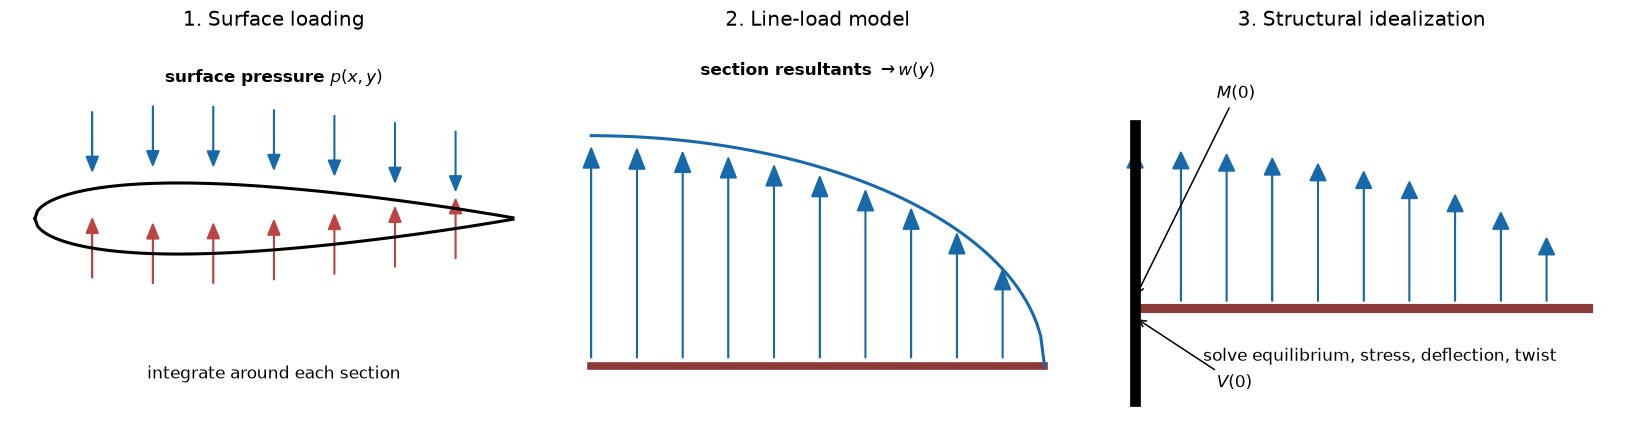

In [2]:
#@title 1. Figure — from a real wing to the beam model { display-mode: "form" }
fig,axs=plt.subplots(1,3,figsize=(15,4))

# Panel 1: pressure on an airfoil section
ax=axs[0]
xx=np.linspace(0,1,180)
yt=5*.12*(.2969*np.sqrt(np.maximum(xx,1e-8))-.126*xx-.3516*xx**2+.2843*xx**3-.1015*xx**4)
ax.plot(xx,yt,'k',lw=2); ax.plot(xx,-yt,'k',lw=2)
for q in np.linspace(.12,.88,7):
    zu=np.interp(q,xx,yt); zl=-zu
    ax.arrow(q,zu+.13,0,-.10,head_width=.025,head_length=.025,color='#1769aa',length_includes_head=True)
    ax.arrow(q,zl-.05,0,.10,head_width=.025,head_length=.025,color='#b44',length_includes_head=True)
ax.text(.5,.23,'surface pressure $p(x,y)$',ha='center',weight='bold')
ax.text(.5,-.27,'integrate around each section',ha='center')
ax.set(xlim=(-.05,1.05),ylim=(-.33,.31),title='1. Surface loading'); ax.axis('off')

# Panel 2: spanwise resultant
ax=axs[1]; yy=np.linspace(0,1,120); ww=np.sqrt(1-yy**2)
ax.plot([0,1],[0,0],color='#8b3a3a',lw=5)
for q,h in zip(yy[::12],ww[::12]):
    ax.arrow(q,.02,0,.52*h,head_width=.035,head_length=.05,color='#1769aa',length_includes_head=True)
ax.plot(yy,.57*ww,color='#1769aa',lw=2)
ax.text(.5,.72,r'section resultants $\rightarrow w(y)$',ha='center',weight='bold')
ax.set(xlim=(-.08,1.08),ylim=(-.12,.82),title='2. Line-load model'); ax.axis('off')

# Panel 3: cantilever idealization
ax=axs[2]; ax.plot([0,1],[0,0],color='#8b3a3a',lw=6); ax.plot([0,0],[-.28,.55],'k',lw=7)
for q,h in zip(yy[::12],ww[::12]):
    ax.arrow(q,.02,0,.45*h,head_width=.035,head_length=.05,color='#1769aa',length_includes_head=True)
ax.annotate('$V(0)$',(0,-.03),xytext=(.18,-.24),arrowprops=dict(arrowstyle='->'))
ax.annotate('$M(0)$',(0,.03),xytext=(.18,.63),arrowprops=dict(arrowstyle='->'))
ax.text(.54,-.16,'solve equilibrium, stress, deflection, twist',ha='center')
ax.set(xlim=(-.08,1.08),ylim=(-.32,.82),title='3. Structural idealization'); ax.axis('off')
plt.tight_layout(); plt.show()

### What was discarded—and why that matters

The reduction above is the central modeling decision:

$$
p(x,y),\;\tau_w(x,y)
\xrightarrow[\text{integrate around section}]{}
w(y),\;m_t(y)
\xrightarrow[\text{beam equilibrium}]{}
V(y),\;M(y),\;T(y).
$$

For a section with chord aligned to the horizontal axis, neglecting skin friction, the pressure contribution to the vertical force per span is

$$
w(y)=\int_{0}^{c}\left[p_{lower}(x,y)-p_{upper}(x,y)\right]dx.
$$

At nonzero angle of attack, rotate chord-axis resultants into flight axes before calling this lift. At nonzero angle of attack, rotate chord-axis resultants into flight axes before calling this lift. Surface pressure therefore becomes a force per unit span. The structural model does not use the individual pressure values after that reduction; it carries their resultant $w(y)$ forward.

The beam model retains the spanwise resultants but discards local skin-pressure detail, rib-to-skin load transfer, holes, joints, and local stress concentrations. Every later result inherits these limitations.

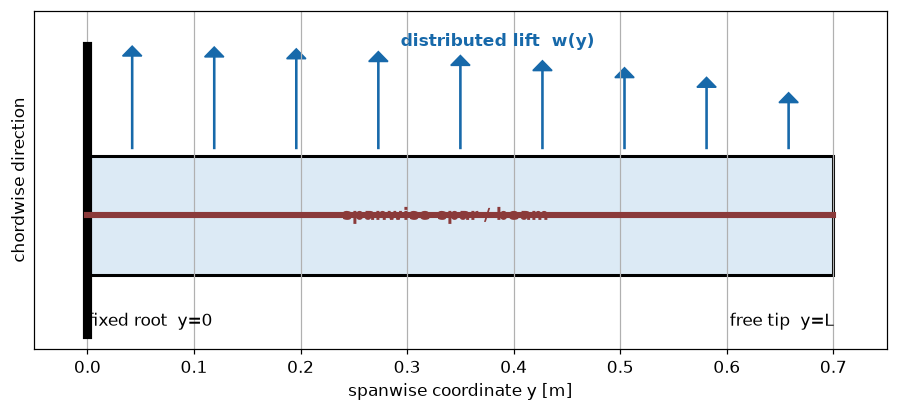

Semispan L = 0.700 m; required semi-wing resultant = 19.620 N


In [3]:
#@title 1A. Visualize the wing, coordinates, and distributed load { display-mode: "form" }
FULL_SPAN_M = 1.40 #@param {type:"number"}
CHORD_M = 0.30 #@param {type:"number"}
MASS_KG = 2.0 #@param {type:"number"}
LOAD_FACTOR = 2.0 #@param {type:"number"}
G = 9.81
L = FULL_SPAN_M/2
F_HALF = LOAD_FACTOR*MASS_KG*G/2

fig, ax = plt.subplots(figsize=(10,4))
ax.add_patch(Rectangle((0,-CHORD_M/2), L, CHORD_M, fc="#dceaf5", ec="black", lw=2))
for yy in np.linspace(0.06*L,0.94*L,9):
    h=0.08+0.18*np.sqrt(max(0,1-(yy/L)**2))
    ax.arrow(yy, CHORD_M/2+0.02, 0, h, head_width=.018, head_length=.025,
             length_includes_head=True, color="#1769aa")
ax.plot([0,0],[-.30,.43],color="black",lw=6)
ax.annotate("fixed root  y=0",(0,-.28),ha="left")
ax.annotate("free tip  y=L",(L,-.28),ha="right")
ax.annotate("distributed lift  w(y)",(0.55*L,.43),ha="center",color="#1769aa",weight="bold")
ax.annotate("spanwise spar / beam",(.48*L,0),ha="center",va="center",color="#8b3a3a",weight="bold")
ax.plot([0,L],[0,0],color="#8b3a3a",lw=4)
ax.set(xlim=(-.05,L+.05),ylim=(-.34,.52),xlabel="spanwise coordinate y [m]",ylabel="chordwise direction")
ax.set_yticks([]); plt.show()
print(f"Semispan L = {L:.3f} m; required semi-wing resultant = {F_HALF:.3f} N")

### Hand calculation 1 — load normalization

Before running the next cell, calculate on paper:

1. $F_{1/2}$ for the values above.
2. The uniform load $w=F_{1/2}/L$.
3. The elliptical peak load $w_0=4F_{1/2}/(\pi L)$.
4. Predict which distribution produces the larger root bending moment, and explain why using the load centroid.

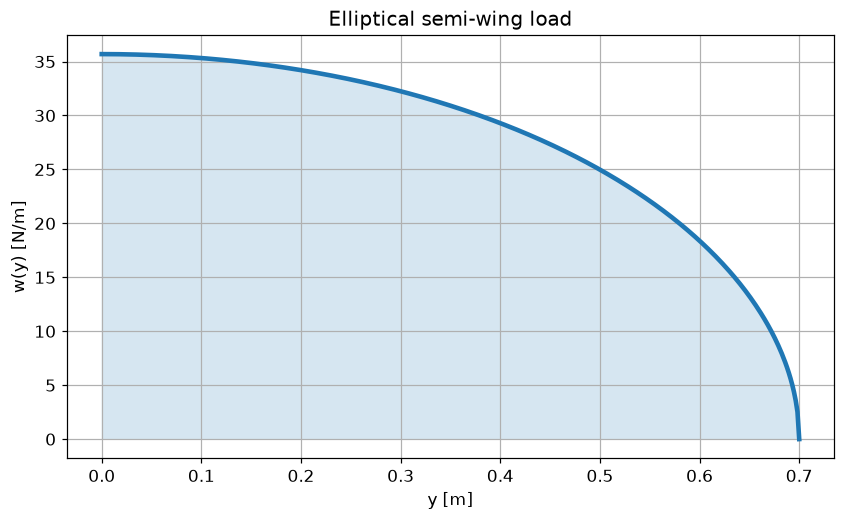

Numerical resultant = 19.61908 N
Target resultant    = 19.62000 N
Relative error      = 0.0047%
Load centroid       = 0.29707 m = 0.4244 L


In [4]:
#@title 1B. Check load normalization numerically { display-mode: "form" }
LOAD_SHAPE = "Elliptical" #@param ["Uniform", "Elliptical"]
N_STATIONS = 401 #@param {type:"integer"}
assert N_STATIONS >= 21
y = np.linspace(0,L,N_STATIONS)
if LOAD_SHAPE == "Uniform":
    w = np.full_like(y, F_HALF/L)
else:
    w = 4*F_HALF/(np.pi*L)*np.sqrt(np.maximum(0,1-(y/L)**2))
F_numeric = np.trapezoid(w,y)
ybar = np.trapezoid(y*w,y)/F_numeric
print(f"Numerical resultant = {F_numeric:.5f} N")
print(f"Target resultant    = {F_HALF:.5f} N")
print(f"Relative error      = {100*abs(F_numeric-F_HALF)/F_HALF:.4f}%")
print(f"Load centroid       = {ybar:.5f} m = {ybar/L:.4f} L")
plt.plot(y,w,lw=3); plt.fill_between(y,w,alpha=.18)
plt.xlabel("y [m]"); plt.ylabel("w(y) [N/m]"); plt.title(f"{LOAD_SHAPE} semi-wing load"); plt.show()

## 2. From distributed load to shear and bending moment

Cut the beam at station $y$ and enforce equilibrium on the outboard segment. Using magnitudes,

$$
V(y)=\int_y^L w(\eta)\,d\eta,
\qquad
M(y)=\int_y^L w(\eta)(\eta-y)\,d\eta.
$$

Equivalent differential relations are $dV/dy=-w$ and $dM/dy=-V$, subject to free-tip conditions $V(L)=M(L)=0$.

For a **uniform load** $w=F_{1/2}/L$, integration gives

$$
V(y)=w(L-y),\qquad M(y)=\frac{w}{2}(L-y)^2,
$$

and therefore $M_{root}=F_{1/2}L/2$. This closed-form result is our first independent check.

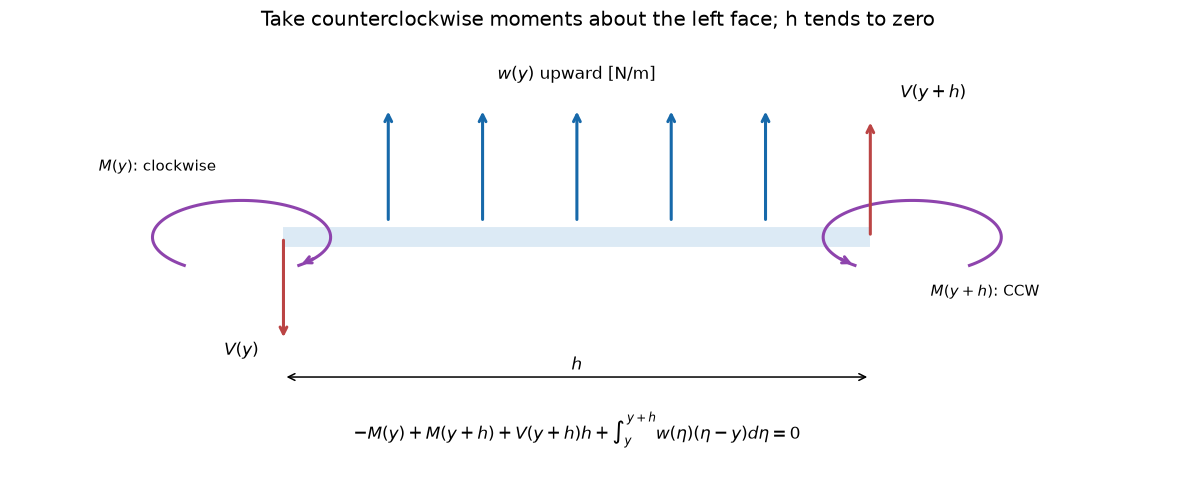

In [5]:
#@title 2. Free-body diagram — upward load, force arrows and moment arrows
from matplotlib.patches import FancyArrowPatch
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot([.22,.78],[.4,.4],lw=13,color='#dceaf5',solid_capstyle='butt')
for xx in np.linspace(.32,.68,5):
    ax.annotate('',xy=(xx,.75),xytext=(xx,.44),arrowprops=dict(arrowstyle='->',color='#1769aa',lw=2))
ax.annotate('',xy=(.22,.12),xytext=(.22,.4),arrowprops=dict(arrowstyle='->',color='#b44',lw=2))
ax.annotate('',xy=(.78,.72),xytext=(.78,.4),arrowprops=dict(arrowstyle='->',color='#b44',lw=2))
ax.text(.18,.08,r'$V(y)$',ha='center'); ax.text(.84,.78,r'$V(y+h)$',ha='center')
def couple(cx, clockwise):
    angles=np.linspace(230, -50,100) if clockwise else np.linspace(-50,230,100)
    rad=np.deg2rad(angles); xx=cx+.085*np.cos(rad); zz=.4+.10*np.sin(rad)
    ax.plot(xx,zz,color='#8e44ad',lw=2)
    ax.annotate('',xy=(xx[-1],zz[-1]),xytext=(xx[-7],zz[-7]),arrowprops=dict(arrowstyle='->',color='#8e44ad',lw=2))
couple(.18,True); couple(.82,False)
ax.text(.10,.58,r'$M(y)$: clockwise',ha='center',fontsize=10)
ax.text(.89,.24,r'$M(y+h)$: CCW',ha='center',fontsize=10)
ax.annotate('',xy=(.78,.02),xytext=(.22,.02),arrowprops=dict(arrowstyle='<->'))
ax.text(.50,.04,r'$h$',ha='center'); ax.text(.50,.83,r'$w(y)$ upward [N/m]',ha='center')
ax.text(.50,-.15,r'$-M(y)+M(y+h)+V(y+h)h+\int_y^{y+h}w(\eta)(\eta-y)d\eta=0$',ha='center')
ax.set(xlim=(-.04,1.08),ylim=(-.23,.95),title='Take counterclockwise moments about the left face; h tends to zero')
ax.axis('off'); plt.tight_layout(); plt.show()

### Derivation from equilibrium — where does the moment equation come from?

There are **two complementary ways** to obtain the moment relation. Use both: the first is the clearest physical definition; the second shows why the differential equation is valid.

#### Method A — take moments of the entire outboard free body

At a cut located at $y$, isolate everything from $y$ to the tip. A small upward load on that outboard piece is

$$
dF=w(\eta)\,d\eta
$$

and its perpendicular lever arm about the cut is $(\eta-y)$. Its contribution to the cut moment is therefore

$$
dM=dF(\eta-y)=w(\eta)(\eta-y)\,d\eta.
$$

Adding all of those contributions from the cut to the tip gives

$$
\boxed{M(y)=\int_y^L w(\eta)(\eta-y)\,d\eta.}
$$

This is the definition used by the code. It says: **moment equals every outboard force multiplied by its own lever arm**. At the root, $y=0$, so $M(0)=\int_0^L\eta w(\eta)d\eta=F_{1/2}\bar y$. The root moment is the resultant lift times the load centroid distance from the root.

#### Unit check — a quick way to catch a wrong formula

$$
[w]=\mathrm{N/m},\qquad [w\,d\eta]=\mathrm{N},\qquad
[w(\eta-y)d\eta]=\mathrm{N\,m}.
$$

Thus the **area under** $w(y)$ is a force, while the **area under a load times its lever arm** is a moment. A force distribution can have the same total area but a different moment if its centroid moves. Moving the same total lift toward the root leaves root shear unchanged but decreases root bending moment.

#### Uniform-load check — derive the familiar result line by line

For $w(\eta)=w_0$,

$$
\begin{aligned}
M(y)&=\int_y^L w_0(\eta-y)\,d\eta\\
&=w_0\left[\frac{(\eta-y)^2}{2}\right]_{\eta=y}^{\eta=L}\\
&=\frac{w_0}{2}(L-y)^2.
\end{aligned}
$$

At the root, $M(0)=w_0L^2/2$. Since $F_{1/2}=w_0L$, this becomes $M_{root}=F_{1/2}L/2$. The resultant of a uniform load acts at $\bar y=L/2$, which gives the same result: $M_{root}=F_{1/2}\bar y$.

Differentiate the boxed expression using the Leibniz rule. The lower-limit term is zero because its lever arm is $(y-y)=0$:

$$
\frac{dM}{dy}=
\underbrace{-w(y)(y-y)}_{0}
+\int_y^L\frac{\partial}{\partial y}\left[w(\eta)(\eta-y)\right]d\eta
=-\int_y^L w(\eta)d\eta
=\boxed{-V(y)}.
$$

#### Method B — take moments of an infinitesimal element

For the element from $y$ to $y+dy$, use **positive internal-resultant magnitudes** and take moments about its left face. Approximating the local load as uniform over this short element, the balance is

$$
M(y)=M(y+dy)+V(y+dy)dy+\left[w(y)dy\right]\frac{dy}{2}.
$$

The three terms on the right are: moment carried by the right face, moment from the right-face shear over lever arm $dy$, and moment from the small distributed load whose resultant acts at $dy/2$. Substitute $M(y+dy)=M(y)+dM$ and $V(y+dy)=V(y)+dV$, divide by $dy$, and take the limit $dy\rightarrow0$:

$$
0=\frac{dM}{dy}+V+\underbrace{dV}_{\rightarrow0}
+\underbrace{\frac{w\,dy}{2}}_{\rightarrow0}
\qquad\Longrightarrow\qquad
\boxed{\frac{dM}{dy}=-V.}
$$

The two discarded terms are of order $dy^2$ before division, so they vanish as the element becomes infinitesimally short. This is not an arbitrary omission; it is the limiting step that converts exact element equilibrium into a differential equation.

Vertical equilibrium of the same element gives

$$
-V+(V+dV)+w\,dy=0
\qquad\Longrightarrow\qquad
\boxed{\frac{dV}{dy}=-w.}
$$

The signs depend on the adopted convention; the magnitude relation and physical equilibrium do not.

> **Sign-convention note.** In this notebook, $w$, $V$, and $M$ in the plots are reported as positive **magnitudes** for an upward aerodynamic load on the semi-wing. The fixed root supplies equal-and-opposite reactions. A conventional signed shear-force or bending-moment diagram may display the same physical state with opposite algebraic signs; never mix its arrows with the magnitude equations without first stating the convention.

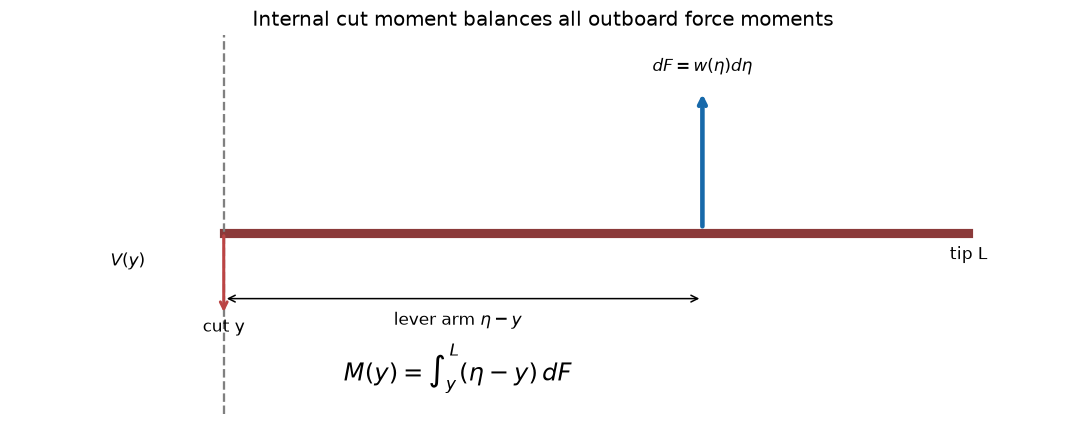

In [6]:
#@title 2. Lever arm of one elemental force on the isolated outboard part
fig,ax=plt.subplots(figsize=(10,4))
ax.plot([.25,.95],[.40,.40],lw=6,color='#8b3a3a')
ax.axvline(.25,color='gray',ls='--'); ax.text(.25,.10,'cut y',ha='center')
ax.text(.95,.32,'tip L',ha='center')
ax.annotate('',xy=(.70,.83),xytext=(.70,.41),arrowprops=dict(arrowstyle='->',color='#1769aa',lw=3))
ax.text(.70,.89,r'$dF=w(\eta)d\eta$',ha='center')
ax.annotate('',xy=(.70,.20),xytext=(.25,.20),arrowprops=dict(arrowstyle='<->'))
ax.text(.47,.12,r'lever arm $\eta-y$',ha='center')
ax.annotate('',xy=(.25,.15),xytext=(.25,.4),arrowprops=dict(arrowstyle='->',color='#b44',lw=2))
ax.text(.16,.30,r'$V(y)$',ha='center')
ax.text(.47,-.05,r'$M(y)=\int_y^L (\eta-y)\,dF$',ha='center',fontsize=16)
ax.set(xlim=(.05,1.05),ylim=(-.15,1),title='Internal cut moment balances all outboard force moments')
ax.axis('off'); plt.tight_layout(); plt.show()

### Hand calculation 2 — root reactions

For the uniform case, calculate $V(0)$ and $M(0)$. Sketch both diagrams and label their values at root and tip. Also calculate $M(0)=F_{1/2}\bar y$ using the uniform-load centroid $\bar y=L/2$. Only then run the numerical cell.

### How the numerical integration represents the theory

The code does not call a black-box structural solver. It represents each integral with small trapezoids. At stations $y_i,y_{i+1},\ldots,y_N$, the shear is approximated as

$$
V_i\approx\sum_{j=i}^{N-1}\frac{w_j+w_{j+1}}{2}\,\Delta y,
$$

and the moment is approximated by the same force samples multiplied by their individual lever arms:

$$
M_i\approx\sum_{j=i}^{N-1}\frac{\Delta y}{2}\left[w_j(y_j-y_i)+w_{j+1}(y_{j+1}-y_i)\right].
$$

We integrate **from the tip inward** because the free-tip boundary conditions are known exactly: $V(L)=0$ and $M(L)=0$. Later, the convergence check tests whether using more stations changes the answer materially.

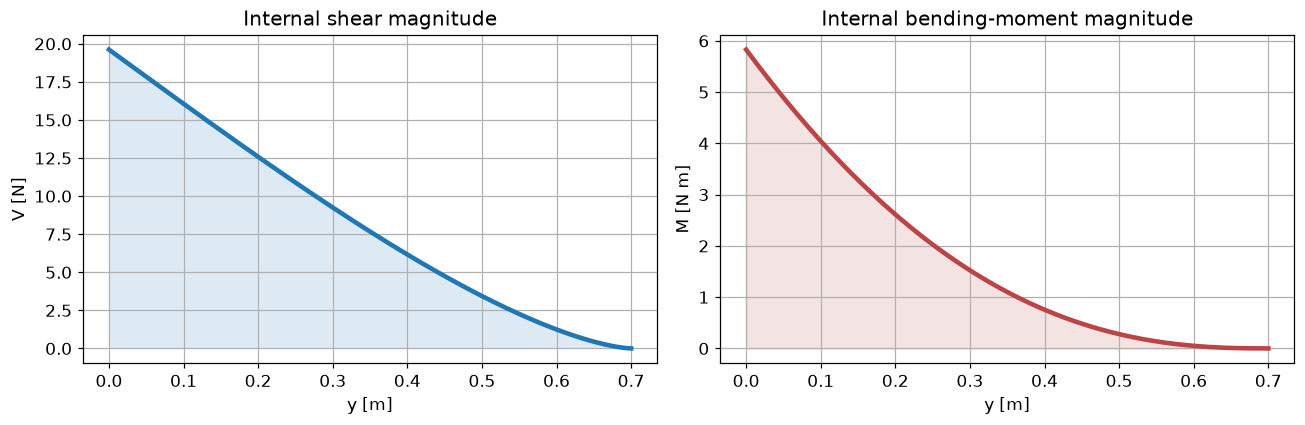

Root shear  = 19.6191 N
Root moment = 5.8282 N m


In [7]:
#@title 2A. Numerical integration of shear and moment { display-mode: "form" }
V = integrate_from_tip(w,y)
M = np.array([np.trapezoid(w[i:]*(y[i:]-y[i]),y[i:]) for i in range(len(y))])

# This is the discrete version of M(y)=integral[w(eta)*(eta-y)deta].
# At station i, every outboard load sample w[j]*Delta_y is multiplied by its lever arm y[j]-y[i].

fig,axs=plt.subplots(1,2,figsize=(12,4))
axs[0].plot(y,V,lw=3); axs[0].fill_between(y,V,alpha=.15); axs[0].set(xlabel="y [m]",ylabel="V [N]",title="Internal shear magnitude")
axs[1].plot(y,M,lw=3,color="#b44"); axs[1].fill_between(y,M,alpha=.15,color="#b44"); axs[1].set(xlabel="y [m]",ylabel="M [N m]",title="Internal bending-moment magnitude")
plt.tight_layout(); plt.show()
print(f"Root shear  = {V[0]:.4f} N")
print(f"Root moment = {M[0]:.4f} N m")
if LOAD_SHAPE == "Uniform":
    exact=F_HALF*L/2
    print(f"Closed-form root moment = {exact:.4f} N m; error = {100*abs(M[0]-exact)/exact:.4g}%")

## 3. Spar-box geometry and bending stress

We idealize the spar as a rectangular closed box with outer width $B$, outer height $H$, cap thickness $t_f$, and web thickness $t_w$. The beam bends about its horizontal centroidal axis.

Subtract the inner void from the outer rectangle:

$$
I=\frac{BH^3-(B-2t_w)(H-2t_f)^3}{12}.
$$

Euler–Bernoulli bending stress is

$$
\sigma_x(y,z)=-\frac{M(y)z}{I},
\qquad
|\sigma_{max}(y)|=\frac{|M(y)|H}{2I}.
$$

One face is in tension and the opposite face is in compression. A stress check uses an allowable value, not merely the raw material strength:

$$
\sigma_{allow}=\frac{\min(\sigma_{t,u},\sigma_{c,u})}{FS},
\qquad
U_\sigma=\frac{\sigma_{max}}{\sigma_{allow}}.
$$

The selected bending check passes when $U_\sigma\le 1$. Local buckling, holes, joints, print anisotropy, and stress concentrations are not represented.

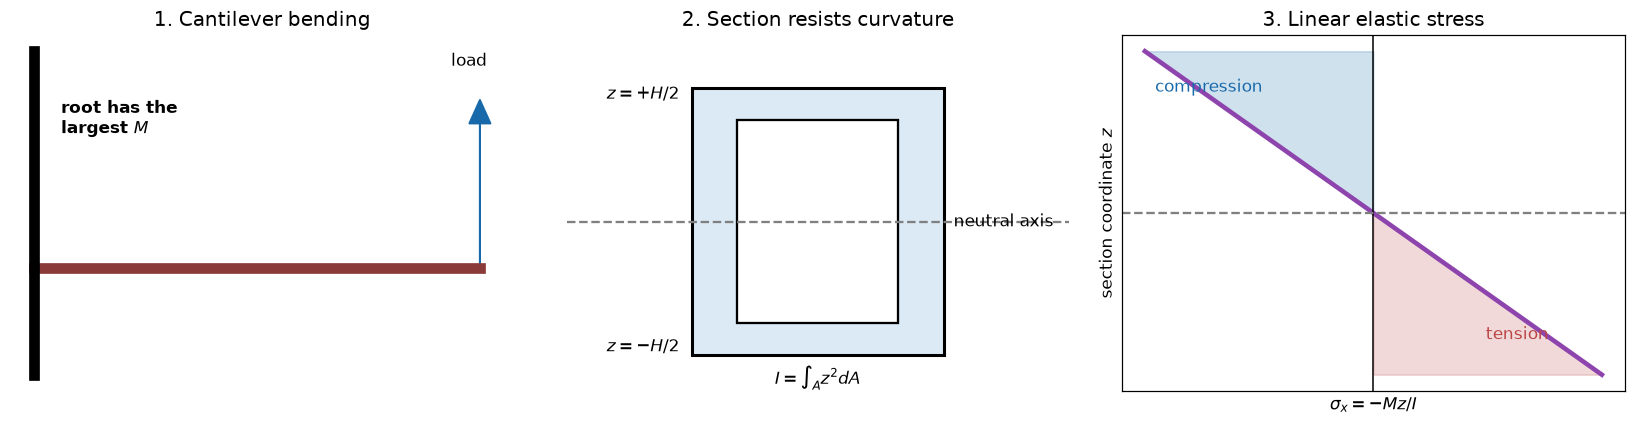

In [8]:
#@title 3. Figure — how bending moment becomes normal stress { display-mode: "form" }
fig,axs=plt.subplots(1,3,figsize=(15,4))
ax=axs[0]; ax.plot([.08,.9],[.3,.3],color='#8b3a3a',lw=7); ax.plot([.08,.08],[.08,.75],'k',lw=7)
ax.annotate('root has the\nlargest $M$',(.13,.58),weight='bold')
ax.arrow(.9,.3,0,.35,head_width=.04,head_length=.05,color='#1769aa',length_includes_head=True)
ax.text(.88,.72,'load',ha='center'); ax.set(title='1. Cantilever bending'); ax.axis('off')

ax=axs[1]
ax.add_patch(Rectangle((.25,.1),.5,.75,fc='#dceaf5',ec='black',lw=2))
ax.add_patch(Rectangle((.34,.19),.32,.57,fc='white',ec='black',lw=1.5))
ax.axhline(.475,color='gray',ls='--'); ax.text(.77,.475,'neutral axis',va='center')
ax.annotate('$z=+H/2$',(.08,.82)); ax.annotate('$z=-H/2$',(.08,.11))
ax.annotate(r'$I=\int_A z^2dA$',(.5,.02),ha='center',weight='bold')
ax.set(title='2. Section resists curvature'); ax.axis('off')

ax=axs[2]
z=np.linspace(-1,1,100); s=-z
ax.plot(s,z,lw=3,color='#8e44ad'); ax.fill_betweenx(z,0,s,where=s>=0,alpha=.2,color='#b44'); ax.fill_betweenx(z,0,s,where=s<0,alpha=.2,color='#1769aa')
ax.axvline(0,color='k',lw=1); ax.axhline(0,color='gray',ls='--')
ax.text(-.72,.75,'compression',ha='center',color='#1769aa'); ax.text(.63,-.78,'tension',ha='center',color='#b44')
ax.set(xlabel=r'$\sigma_x=-Mz/I$',ylabel='section coordinate $z$',title='3. Linear elastic stress'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### Why section depth is powerful

The $z^2$ in $I=\int_A z^2dA$ means material placed far from the neutral axis contributes disproportionately to bending stiffness. That is why wing spars use separated caps joined by webs. The caps carry most bending normal force; the webs connect them and carry important shear flow. Increasing height can therefore reduce both stress $Mc/I$ and curvature $M/EI$, but the airfoil imposes a geometric limit.

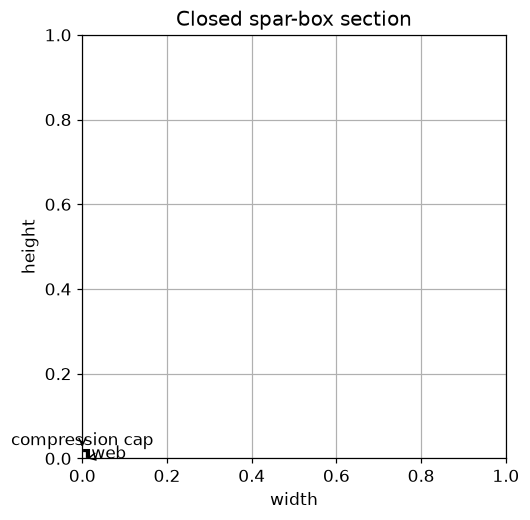

Area A = 244.00 mm²; I = 51685.33 mm⁴
Root extreme stress = 2.255 MPa
Allowable stress = 120.000 MPa; utilization = 0.0188
Idealized semi-span spar mass = 0.4612 kg


In [9]:
#@title 3A. Define material and spar-box geometry { display-mode: "form" }
E_GPA = 70.0 #@param {type:"number"}
G_GPA = 26.0 #@param {type:"number"}
DENSITY_KG_M3 = 2700.0 #@param {type:"number"}
TENSILE_STRENGTH_MPA = 300.0 #@param {type:"number"}
COMPRESSIVE_STRENGTH_MPA = 240.0 #@param {type:"number"}
FACTOR_OF_SAFETY = 2.0 #@param {type:"number"}
B_MM = 25.0 #@param {type:"number"}
H_MM = 40.0 #@param {type:"number"}
CAP_T_MM = 2.0 #@param {type:"number"}
WEB_T_MM = 2.0 #@param {type:"number"}

B,H,tf,tw = np.array([B_MM,H_MM,CAP_T_MM,WEB_T_MM])*1e-3
assert B>2*tw and H>2*tf and min(E_GPA,G_GPA,DENSITY_KG_M3,FACTOR_OF_SAFETY)>0
A = B*H-(B-2*tw)*(H-2*tf)
I = (B*H**3-(B-2*tw)*(H-2*tf)**3)/12
allow = min(TENSILE_STRENGTH_MPA,COMPRESSIVE_STRENGTH_MPA)*1e6/FACTOR_OF_SAFETY
sigma = M*(H/2)/I
util = sigma.max()/allow
mass_spar = DENSITY_KG_M3*A*L

fig,ax=plt.subplots(figsize=(5,5))
ax.add_patch(Rectangle((-B/2,-H/2),B,H,fc="#d4e6f1",ec="black",lw=2))
ax.add_patch(Rectangle((-(B-2*tw)/2,-(H-2*tf)/2),B-2*tw,H-2*tf,fc="white",ec="black",lw=1.5))
ax.annotate("compression cap",(0,H/2),xytext=(0,H*.78),ha="center",arrowprops=dict(arrowstyle="->"))
ax.annotate("tension cap",(0,-H/2),xytext=(0,-H*.78),ha="center",arrowprops=dict(arrowstyle="->"))
ax.annotate("web",(B/2-tw/2,0),xytext=(B*.85,0),arrowprops=dict(arrowstyle="->"))
ax.set_aspect('equal'); ax.set(xlabel="width",ylabel="height",title="Closed spar-box section"); plt.show()
print(f"Area A = {A*1e6:.2f} mm²; I = {I*1e12:.2f} mm⁴")
print(f"Root extreme stress = {sigma[0]/1e6:.3f} MPa")
print(f"Allowable stress = {allow/1e6:.3f} MPa; utilization = {util:.4f}")
print(f"Idealized semi-span spar mass = {mass_spar:.4f} kg")

### Hand calculation 3 — section and stress

Using the displayed dimensions, independently calculate $I$, root extreme stress, and utilization. Report units at every step. Explain why increasing $H$ is usually more efficient for bending stiffness than increasing $B$.

## 4. Deflection from curvature

For a slender Euler–Bernoulli beam with constant $EI$,

$$
\kappa(y)=\frac{d^2v}{dy^2}=\frac{M(y)}{EI}.
$$

The fixed-root boundary conditions are $v(0)=0$ and $dv/dy|_{0}=0$. Therefore, numerical integration proceeds from the root:

$$
\theta_b(y)=\int_0^y\frac{M(\xi)}{EI}\,d\xi,
\qquad
v(y)=\int_0^y\theta_b(\xi)\,d\xi.
$$

For a uniform load, the closed-form tip deflection is

$$
v(L)=\frac{wL^4}{8EI}=\frac{F_{1/2}L^3}{8EI}.
$$

This equation is an independent benchmark for the numerical integrator.

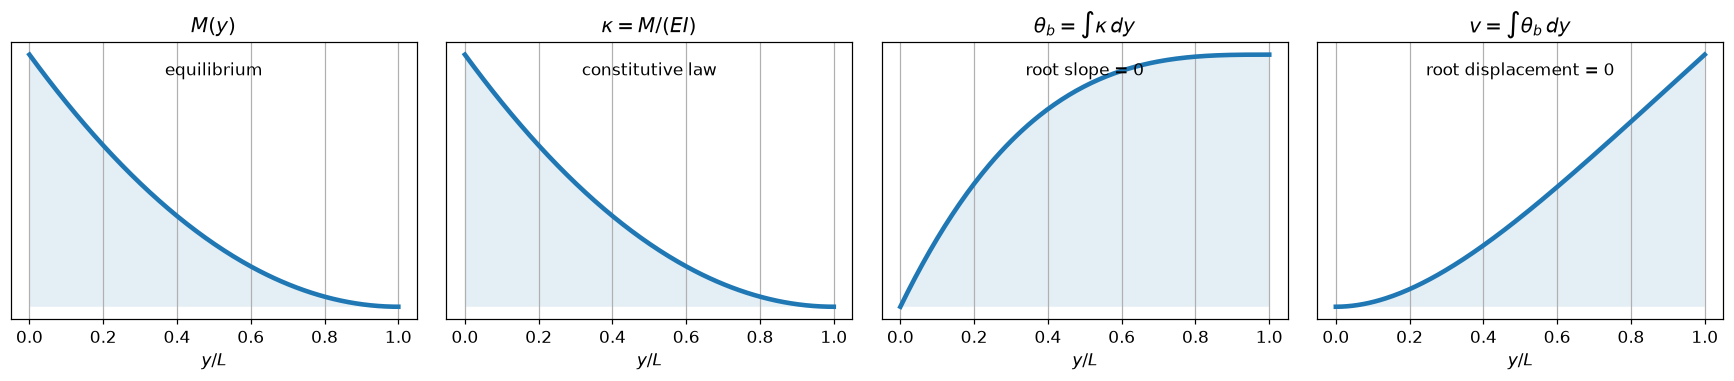

In [10]:
#@title 4. Figure — moment → curvature → slope → deflection { display-mode: "form" }
fig,axs=plt.subplots(1,4,figsize=(16,3.6))
u=np.linspace(0,1,200)
cur=(1-u)**2; sl=u-u**2+u**3/3; de=.5*u**2-u**3/3+u**4/12
items=[(cur,r'$M(y)$','equilibrium'),(cur,r'$\kappa=M/(EI)$','constitutive law'),(sl,r'$\theta_b=\int\kappa\,dy$','root slope = 0'),(de,r'$v=\int\theta_b\,dy$','root displacement = 0')]
for ax,(q,title,sub) in zip(axs,items):
    ax.plot(u,q,lw=3); ax.fill_between(u,q,alpha=.12); ax.set(xlabel='$y/L$',title=title); ax.text(.5,.88,sub,transform=ax.transAxes,ha='center'); ax.set_yticks([])
plt.tight_layout(); plt.show()

The two integrations are not optional numerical tricks: they impose the kinematic meaning of curvature. A wrong integration direction or wrong boundary condition may produce a smooth-looking but physically impossible deflected shape. Always verify $v(0)=0$, $v'(0)=0$, and grid convergence.

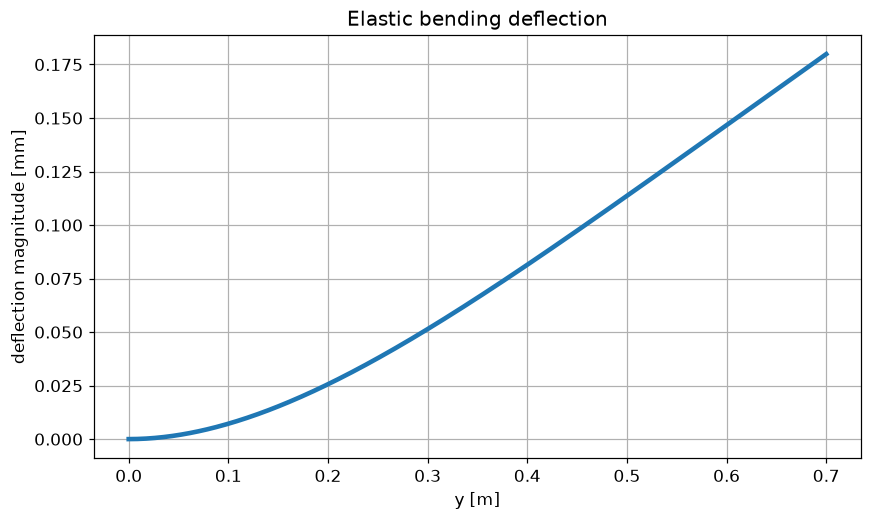

Numerical tip deflection = 0.17985 mm

Grid convergence: number of stations → tip deflection [mm]
  21 → 0.177149
  51 → 0.179199
 101 → 0.179641
 201 → 0.179795
 401 → 0.179849
 801 → 0.179869


In [11]:
#@title 4A. Integrate curvature and perform a convergence check { display-mode: "form" }
E = E_GPA*1e9
curvature = M/(E*I)
slope = cumtrapz_from_root(curvature,y)
v = cumtrapz_from_root(slope,y)

plt.plot(y,1000*v,lw=3)
plt.xlabel("y [m]"); plt.ylabel("deflection magnitude [mm]"); plt.title("Elastic bending deflection"); plt.show()
print(f"Numerical tip deflection = {1000*v[-1]:.5f} mm")
if LOAD_SHAPE == "Uniform":
    exact=F_HALF*L**3/(8*E*I)
    print(f"Closed-form tip deflection = {1000*exact:.5f} mm")
    print(f"Relative error = {100*abs(v[-1]-exact)/exact:.5f}%")

print("\nGrid convergence: number of stations → tip deflection [mm]")
for nn in [21,51,101,201,401,801]:
    yy=np.linspace(0,L,nn)
    ww=np.full_like(yy,F_HALF/L) if LOAD_SHAPE=="Uniform" else 4*F_HALF/(np.pi*L)*np.sqrt(np.maximum(0,1-(yy/L)**2))
    MM=np.array([np.trapezoid(ww[i:]*(yy[i:]-yy[i]),yy[i:]) for i in range(nn)])
    vv=cumtrapz_from_root(cumtrapz_from_root(MM/(E*I),yy),yy)
    print(f"{nn:4d} → {1000*vv[-1]:.6f}")

## 5. Torsion of a thin-walled closed section

If the lift resultant acts a chordwise distance $e$ from the shear center, it produces distributed torque

$$
m_t(y)=e\,w(y).
$$

The internal torque is $T(y)=\int_y^L m_t(\eta)d\eta$. For a single-cell, thin-walled closed section,

$$
J\approx\frac{4A_m^2}{\oint ds/t},
\qquad
\frac{d\phi}{dy}=\frac{T(y)}{GJ}.
$$

For the rectangular median line,

$$
A_m=(B-t_w)(H-t_f),\quad
\oint\frac{ds}{t}=\frac{2(B-t_w)}{t_f}+\frac{2(H-t_f)}{t_w}.
$$

This Bredt–Batho model assumes a closed, thin-walled cell. An open or cracked section can be much less torsionally stiff.

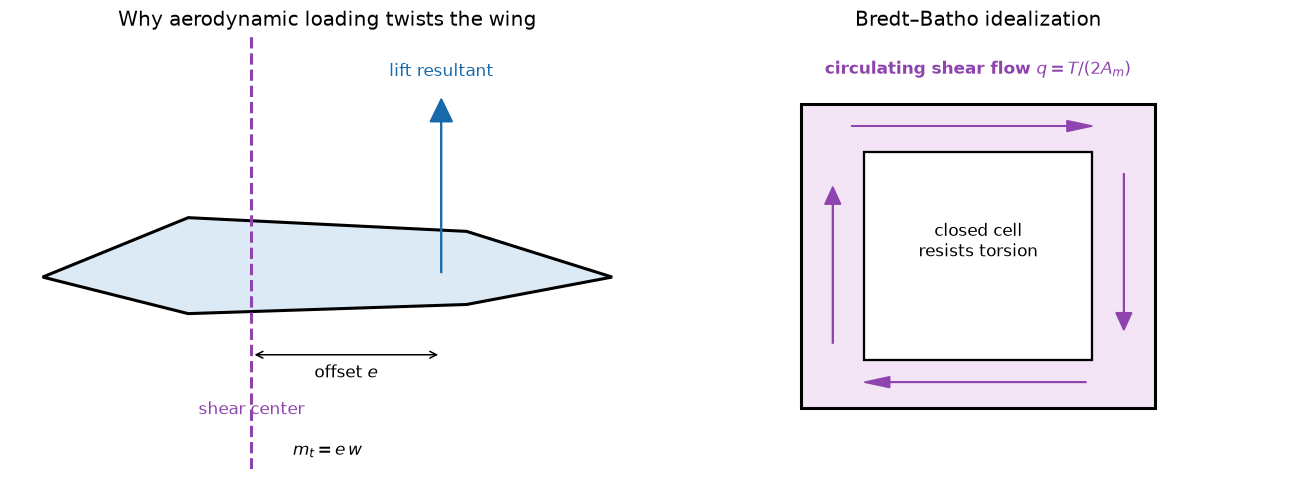

In [12]:
#@title 5. Figure — eccentric lift, torque, and closed-cell shear flow { display-mode: "form" }
fig,axs=plt.subplots(1,2,figsize=(12,4.5))
ax=axs[0]
air=np.array([[.05,.42],[.28,.55],[.72,.52],[.95,.42],[.72,.36],[.28,.34]])
ax.add_patch(Polygon(air,closed=True,fc='#dceaf5',ec='black',lw=2))
ax.axvline(.38,color='#8e44ad',ls='--',lw=2); ax.text(.38,.12,'shear center',ha='center',color='#8e44ad')
ax.arrow(.68,.43,0,.38,head_width=.035,head_length=.05,color='#1769aa',length_includes_head=True)
ax.text(.68,.86,'lift resultant',ha='center',color='#1769aa')
ax.annotate('',xy=(.68,.25),xytext=(.38,.25),arrowprops=dict(arrowstyle='<->'))
ax.text(.53,.20,'offset $e$',ha='center'); ax.text(.5,.03,r'$m_t=e\,w$',ha='center',weight='bold')
ax.set(xlim=(0,1),ylim=(0,.95),title='Why aerodynamic loading twists the wing'); ax.axis('off')

ax=axs[1]
ax.add_patch(Rectangle((.22,.14),.56,.70,fc='#f3e5f5',ec='black',lw=2))
ax.add_patch(Rectangle((.32,.25),.36,.48,fc='white',ec='black',lw=1.5))
for x0,y0,dx,dy in [(.30,.79,.38,0),(.73,.68,0,-.36),(.67,.20,-.35,0),(.27,.29,0,.36)]:
    ax.arrow(x0,y0,dx,dy,head_width=.025,head_length=.04,color='#8e44ad',length_includes_head=True)
ax.text(.5,.91,'circulating shear flow $q=T/(2A_m)$',ha='center',color='#8e44ad',weight='bold')
ax.text(.5,.49,'closed cell\nresists torsion',ha='center')
ax.set(xlim=(0,1),ylim=(0,1),title='Bredt–Batho idealization'); ax.axis('off')
plt.tight_layout(); plt.show()

For a single closed cell, equilibrium gives the nearly constant shear flow $q=T/(2A_m)$. Wall shear stress is $\tau=q/t$, so thinner walls experience greater shear stress. Compatibility around the cell then produces $J$ and the twist rate $T/(GJ)$. This is why closing a wing box dramatically improves torsional stiffness compared with an open channel.

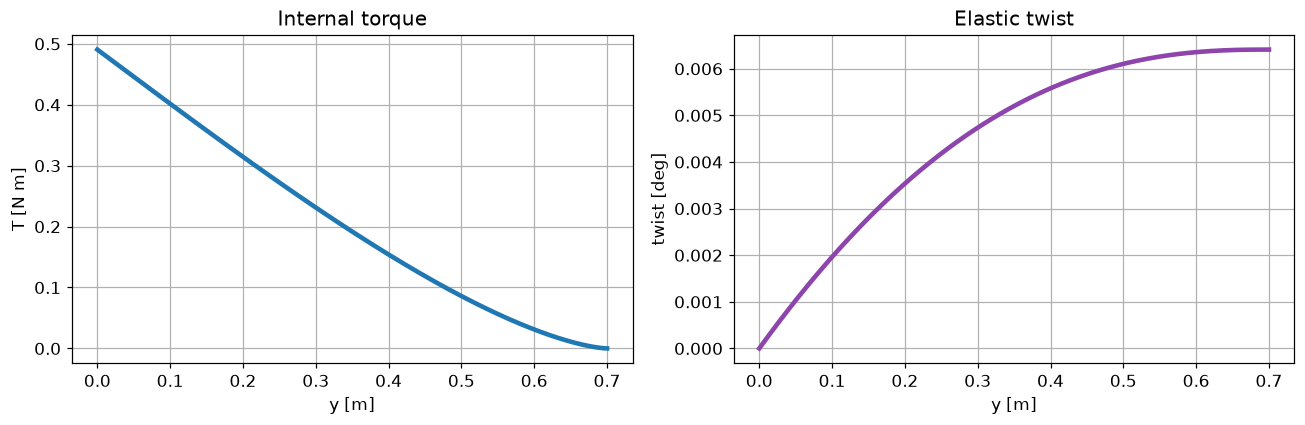

Thin-wall torsion constant J = 50090.23 mm⁴
Tip twist = 0.00641 deg; limit = 3.000 deg


In [13]:
#@title 5A. Compute torque and twist { display-mode: "form" }
OFFSET_E_MM = 25.0 #@param {type:"number"}
TWIST_LIMIT_DEG = 3.0 #@param {type:"number"}
e=OFFSET_E_MM*1e-3; Gmat=G_GPA*1e9
Bm=B-tw; Hm=H-tf; Am=Bm*Hm
J=4*Am**2/(2*Bm/tf+2*Hm/tw)
mt=e*w
T=integrate_from_tip(mt,y)
phi=cumtrapz_from_root(T/(Gmat*J),y)
fig,axs=plt.subplots(1,2,figsize=(12,4))
axs[0].plot(y,T,lw=3); axs[0].set(xlabel="y [m]",ylabel="T [N m]",title="Internal torque")
axs[1].plot(y,np.degrees(phi),lw=3,color="#8e44ad"); axs[1].set(xlabel="y [m]",ylabel="twist [deg]",title="Elastic twist")
plt.tight_layout(); plt.show()
print(f"Thin-wall torsion constant J = {J*1e12:.2f} mm⁴")
print(f"Tip twist = {np.degrees(phi[-1]):.5f} deg; limit = {TWIST_LIMIT_DEG:.3f} deg")

## 6. Can the spar fit inside the airfoil?

A structurally adequate box is unusable if it intersects the airfoil skin. We use the standard NACA four-digit construction. For NACA $MPXX$:

- maximum camber $m=M/100$,
- camber location $p=P/10$,
- thickness ratio $t=XX/100$.

The thickness distribution is

$$
y_t=5tc\left(0.2969\sqrt{x/c}-0.1260x/c-0.3516(x/c)^2+0.2843(x/c)^3-0.1015(x/c)^4\right).
$$

The camber line and its slope locate the upper and lower surfaces. The code below evaluates the surfaces at both sides of the spar box and reports the minimum vertical clearance. Numerical clearance is only a screening check; CAD interference should still be checked before manufacture.

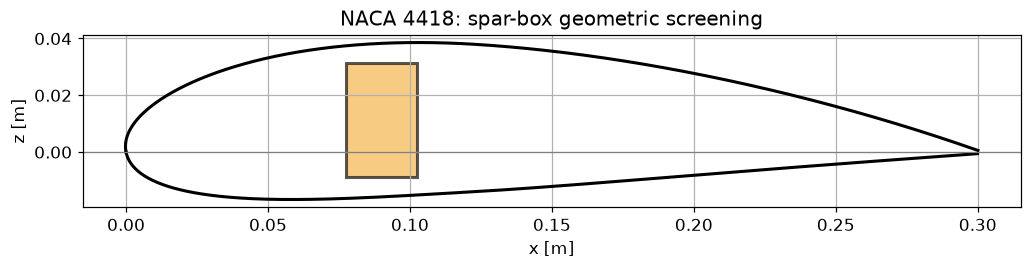

Minimum geometric clearance = 6.221 mm
Clearance check: PASS


In [14]:
#@title 6A. Plot a NACA airfoil and check spar clearance { display-mode: "form" }
NACA = "4418" #@param {type:"string"}
BOX_CENTER_XC = 0.30 #@param {type:"number"}
SKIN_CLEARANCE_MM = 2.0 #@param {type:"number"}

assert len(NACA)==4 and NACA.isdigit()
m=int(NACA[0])/100; p=int(NACA[1])/10; thick=int(NACA[2:])/100
beta=np.linspace(0,np.pi,401); xn=(1-np.cos(beta))/2
yt=5*thick*(.2969*np.sqrt(xn)-.1260*xn-.3516*xn**2+.2843*xn**3-.1015*xn**4)
yc=np.zeros_like(xn); dyc=np.zeros_like(xn)
left=xn<p
if m>0 and p>0:
    yc[left]=m/p**2*(2*p*xn[left]-xn[left]**2); dyc[left]=2*m/p**2*(p-xn[left])
    yc[~left]=m/(1-p)**2*((1-2*p)+2*p*xn[~left]-xn[~left]**2); dyc[~left]=2*m/(1-p)**2*(p-xn[~left])
theta=np.arctan(dyc)
xu=(xn-yt*np.sin(theta))*CHORD_M; yu=(yc+yt*np.cos(theta))*CHORD_M
xl=(xn+yt*np.sin(theta))*CHORD_M; yl=(yc-yt*np.cos(theta))*CHORD_M

x1=(BOX_CENTER_XC*CHORD_M-B/2); x2=(BOX_CENTER_XC*CHORD_M+B/2)
xs=np.linspace(x1,x2,101)
upper=np.interp(xs,np.sort(xu),yu[np.argsort(xu)])
lower=np.interp(xs,np.sort(xl),yl[np.argsort(xl)])
box_y=(np.mean(np.r_[upper,lower]))
clear=np.minimum(upper-(box_y+H/2),(box_y-H/2)-lower)

fig,ax=plt.subplots(figsize=(11,4))
ax.plot(xu,yu,'k',lw=2); ax.plot(xl,yl,'k',lw=2)
ax.add_patch(Rectangle((x1,box_y-H/2),B,H,fc="#f5b041",ec="black",alpha=.65,lw=2))
ax.axhline(0,color='gray',lw=.8); ax.set_aspect('equal',adjustable='box')
ax.set(xlabel="x [m]",ylabel="z [m]",title=f"NACA {NACA}: spar-box geometric screening")
plt.show()
min_clear=clear.min()
print(f"Minimum geometric clearance = {1000*min_clear:.3f} mm")
print("Clearance check:", "PASS" if min_clear*1000>=SKIN_CLEARANCE_MM else "FAIL")

## 7. Integrated design decision

A candidate passes the **selected** checks when all of the following are satisfied:

$$
\sigma_{max}\le\sigma_{allow},\qquad
v_{tip}\le v_{limit},\qquad
|\phi_{tip}|\le\phi_{limit},\qquad
\text{clearance}\ge\text{required clearance}.
$$

The objective is to minimize idealized spar mass $m_s=\rho A L$. This is a constrained design problem, not an unconstrained search for the smallest dimensions.

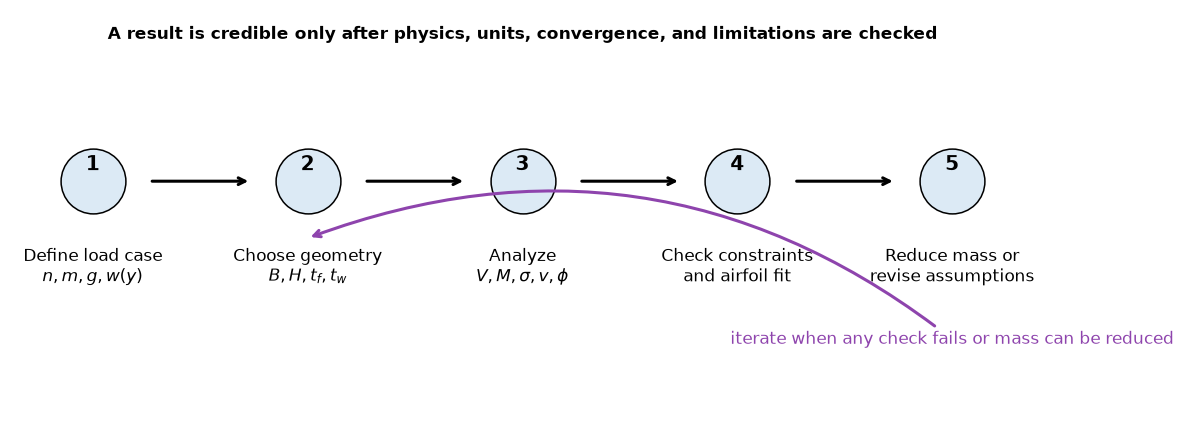

In [15]:
#@title 7. Figure — the iterative engineering-design loop { display-mode: "form" }
fig,ax=plt.subplots(figsize=(12,4.8))
labels=[('1','Define load case\n$n,m,g,w(y)$'),('2','Choose geometry\n$B,H,t_f,t_w$'),('3','Analyze\n'+r'$V,M,\sigma,v,\phi$'),('4','Check constraints\nand airfoil fit'),('5','Reduce mass or\nrevise assumptions')]
xs=np.linspace(.08,.92,len(labels)); yy=.58
for x,(num,lab) in zip(xs,labels):
    ax.scatter([x],[yy],s=1800,facecolor='#dceaf5',edgecolor='black',zorder=3)
    ax.text(x,yy+.04,num,ha='center',va='center',weight='bold',fontsize=13)
    ax.text(x,yy-.16,lab,ha='center',va='top')
for a,b in zip(xs[:-1],xs[1:]): ax.annotate('',xy=(b-.055,yy),xytext=(a+.055,yy),arrowprops=dict(arrowstyle='->',lw=2))
ax.annotate('iterate when any check fails or mass can be reduced',xy=(xs[1],.44),xytext=(xs[4],.18),ha='center',arrowprops=dict(arrowstyle='->',connectionstyle='arc3,rad=.28',lw=2,color='#8e44ad'),color='#8e44ad')
ax.text(.5,.93,'A result is credible only after physics, units, convergence, and limitations are checked',ha='center',weight='bold')
ax.set(xlim=(0,1),ylim=(0,1)); ax.axis('off'); plt.show()

In [16]:
#@title 7A. Design dashboard { display-mode: "form" }
DEFLECTION_LIMIT_MM = 15.0 #@param {type:"number"}
checks={
    "Bending stress": util<=1,
    "Tip deflection": 1000*v[-1]<=DEFLECTION_LIMIT_MM,
    "Tip twist": abs(np.degrees(phi[-1]))<=TWIST_LIMIT_DEG,
    "Airfoil clearance": 1000*min_clear>=SKIN_CLEARANCE_MM,
}
print("SELECTED DESIGN CHECKS")
for name,ok in checks.items(): print(f"{'PASS' if ok else 'FAIL':4s}  {name}")
print(f"\nIdealized semi-span spar mass: {mass_spar:.4f} kg")
print("Overall:", "MEETS SELECTED CHECKS" if all(checks.values()) else "REVISION REQUIRED")
print("\nThis result does NOT check local buckling, transverse shear, joints, fatigue, damage tolerance,")
print("stress concentrations, manufacturing defects, combined failure, or printed-material anisotropy.")

SELECTED DESIGN CHECKS
PASS  Bending stress
PASS  Tip deflection
PASS  Tip twist
PASS  Airfoil clearance

Idealized semi-span spar mass: 0.4612 kg
Overall: MEETS SELECTED CHECKS

This result does NOT check local buckling, transverse shear, joints, fatigue, damage tolerance,
stress concentrations, manufacturing defects, combined failure, or printed-material anisotropy.


### Team design challenge

Change only the dimensions and material properties you can justify. Find a lighter feasible design.

Your engineering record must include:

1. a baseline design and its governing constraint;
2. at least three documented design revisions;
3. one manual calculation matching the notebook;
4. a grid-convergence result;
5. the final stress, deflection, twist, clearance, and mass;
6. one reason the model may be nonconservative;
7. one additional analysis you would perform before approving a real aircraft component.

Do not claim that “the wing is safe.” State precisely: **the candidate meets the selected checks under the stated assumptions.**

## 8. Numerical design studio — a complete design cycle

The preceding sections derived the equations. This studio uses them to make and defend a design. It follows the progression **inputs → loads → structural sizing → geometric fit → independent verification → revision**, inspired by the supplied [wing-design tutorial](https://www.youtube.com/watch?v=KbvpDjdusuE).

**Teaching route:** session 1 covers the physical model through bending and torsion; session 2 covers geometry, shear, buckling and FEM. Use optimization and uncertainty as the team studio. The full notebook is deliberately longer than one class.

The box stays straight and prismatic. Taper changes the airfoil envelope around it; it does not silently change its section stiffness. We use projected semispan as beam length and neglect the small planform sweep coupling introduced by taper. We prescribe aerodynamic load shapes rather than claim to solve the flow. Gross lift is $nmg/2$ per semi-wing; wing weight/inertial relief is omitted. Aircraft mass is held fixed while spar mass is optimized.

### One input panel for the studio

| Input | Meaning | Input units → calculation units |
|---|---|---|
| Span, root chord, taper | Full span $2L$, root chord $c_r$, $c_t/c_r$ | m, m, dimensionless |
| $B,H,t_f,t_w$ | Box width, height, cap and web thickness | mm → m |
| $E,\nu,G$ | Isotropic elastic constants; $G=E/[2(1+\nu)]$ | GPa → Pa |
| $\rho$ | Density | kg/m³ |
| Strengths and factors | Demonstration material capacities and safety factors | MPa → Pa |
| $e$ | Prescribed force-line offset from box shear center | mm → m |
| Clearance, displacement, twist | Design constraints | mm, mm, degrees → SI |

Material values are an **illustrative isotropic material card**, not certified properties or printed-polymer data. The symmetric box shear center is its centroid; attached skin/ribs could change it. Here $e$ is prescribed and held constant. A complete aerodynamic pitching-moment model is outside this lesson.

Edit the panel and **run all following cells**. Each studio run rebuilds its configuration so results do not quietly mix old and new input values.

In [17]:
#@title 8A. Studio inputs — edit these fields, then rerun all below
STUDIO_SPAN_M = 1.40 #@param {type:"number"}
ROOT_CHORD_M = 0.30 #@param {type:"number"}
TAPER_RATIO = 0.85 #@param {type:"number"}
STUDIO_MASS_KG = 2.0 #@param {type:"number"}
POSITIVE_N = 3.0 #@param {type:"number"}
NEGATIVE_N = -1.5 #@param {type:"number"}
STUDIO_B_MM = 25.0 #@param {type:"number"}
STUDIO_H_MM = 32.0 #@param {type:"number"}
STUDIO_CAP_MM = 1.0 #@param {type:"number"}
STUDIO_WEB_MM = 1.0 #@param {type:"number"}
STUDIO_E_GPA = 70.0 #@param {type:"number"}
POISSON = 0.33 #@param {type:"number"}
STUDIO_DENSITY = 2700.0 #@param {type:"number"}
NORMAL_STRENGTH_MPA = 240.0 #@param {type:"number"}
SHEAR_STRENGTH_MPA = 140.0 #@param {type:"number"}
STRENGTH_FACTOR = 2.0 #@param {type:"number"}
BUCKLING_FACTOR = 1.5 #@param {type:"number"}
STUDIO_OFFSET_MM = 25.0 #@param {type:"number"}
MAX_DEFLECTION_MM = 5.0 #@param {type:"number"}
MAX_TWIST_DEG = 1.0 #@param {type:"number"}
REQUIRED_GAP_MM = 2.0 #@param {type:"number"}
STUDIO_NACA = '4418' #@param {type:"string"}
SPAR_POSITION_XC = 0.30 #@param {type:"number"}
if STRENGTH_FACTOR<=0 or POSITIVE_N<=0 or NEGATIVE_N>=0:
    raise ValueError('Use positive safety factor and positive/negative load factors as labeled.')
cfg=dict(L=STUDIO_SPAN_M/2,c_root=ROOT_CHORD_M,taper=TAPER_RATIO,mass=STUDIO_MASS_KG,
    g=9.81,n=POSITIVE_N,B=STUDIO_B_MM/1000,H=STUDIO_H_MM/1000,tf=STUDIO_CAP_MM/1000,tw=STUDIO_WEB_MM/1000,
    E=STUDIO_E_GPA*1e9,G=STUDIO_E_GPA*1e9/(2*(1+POISSON)),nu=POISSON,rho=STUDIO_DENSITY,
    stress_allow=NORMAL_STRENGTH_MPA*1e6/STRENGTH_FACTOR,shear_allow=SHEAR_STRENGTH_MPA*1e6/STRENGTH_FACTOR,
    buckling_fs=BUCKLING_FACTOR,k_buckle=4.,e=STUDIO_OFFSET_MM/1000,
    defl_limit=MAX_DEFLECTION_MM/1000,twist_limit=np.radians(MAX_TWIST_DEG),clearance=REQUIRED_GAP_MM/1000,
    naca=STUDIO_NACA,spar_xc=SPAR_POSITION_XC)
cases={'Cruise +1g':1.,'Positive maneuver':POSITIVE_N,'Reversed load':NEGATIVE_N}
print('Studio configuration ready. These are teaching load cases, not a regulatory flight envelope.')

Studio configuration ready. These are teaching load cases, not a regulatory flight envelope.


In [18]:
#@title 8B. Transparent calculation functions — run once per studio revision
"""Teaching model embedded into the self-contained wing design notebook. SI units."""
import numpy as np

def integral(f, x):
    return np.sum((np.asarray(f)[1:]+np.asarray(f)[:-1])*np.diff(x)/2)

def cumulative(f, x):
    return np.r_[0., np.cumsum((np.asarray(f)[1:]+np.asarray(f)[:-1])*np.diff(x)/2)]

def section(B, H, tf, tw):
    if min(B,H,tf,tw)<=0 or B<=2*tw or H<=2*tf:
        raise ValueError('Box dimensions must be positive with a positive inner void.')
    bm, hm = B-tw, H-tf
    return dict(A=B*H-(B-2*tw)*(H-2*tf),
                I=(B*H**3-(B-2*tw)*(H-2*tf)**3)/12,
                Am=bm*hm, J=4*(bm*hm)**2/(2*bm/tf+2*hm/tw),
                hweb=H-2*tf, bpanel=B-2*tw,
                thin_ratio=max(tf/bm,tw/hm))

def line_load(y, L, F, shape='Elliptical'):
    r=np.asarray(y)/L
    if shape=='Uniform': return np.ones_like(r)*F/L
    if shape=='Elliptical': return 4*F/(np.pi*L)*np.sqrt(np.maximum(0,1-r*r))
    if shape=='Root-heavy': return 2*F/L*(1-r)
    raise ValueError('Unknown load shape')

def beam_integral(y, w, E, I, G, J, e):
    # M = integral(eta*w) - y*integral(w); O(N) rather than N separate integrals.
    shear=integral(w,y)-cumulative(w,y)
    moment=integral(y*w,y)-cumulative(y*w,y)-y*shear
    torque=e*shear
    slope=cumulative(moment/(E*I),y)
    return dict(y=y,w=w,V=shear,M=moment,T=torque,
                slope=slope,v=cumulative(slope,y),phi=cumulative(torque/(G*J),y))

def airfoil(naca, points=501):
    if len(naca)!=4 or not naca.isdigit() or int(naca[2:])==0:
        raise ValueError('Use a four-digit NACA code with nonzero thickness.')
    m,p,t=int(naca[0])/100,int(naca[1])/10,int(naca[2:])/100
    if m>0 and p==0: raise ValueError('Cambered NACA section requires p > 0.')
    x=(1-np.cos(np.linspace(0,np.pi,points)))/2
    yt=5*t*(.2969*np.sqrt(x)-.126*x-.3516*x*x+.2843*x**3-.1015*x**4)
    yc=np.zeros_like(x); dy=np.zeros_like(x)
    if m:
        k=x<p
        yc[k]=m/p**2*(2*p*x[k]-x[k]**2); dy[k]=2*m/p**2*(p-x[k])
        yc[~k]=m/(1-p)**2*(1-2*p+2*p*x[~k]-x[~k]**2)
        dy[~k]=2*m/(1-p)**2*(p-x[~k])
    th=np.arctan(dy)
    return x-yt*np.sin(th),yc+yt*np.cos(th),x+yt*np.sin(th),yc-yt*np.cos(th)

def packaging(c, B=None, H=None, stations=21):
    B=c['B'] if B is None else B; H=c['H'] if H is None else H
    span=np.linspace(0,c['L'],stations)
    chords=c['c_root']*(1-(1-c['taper'])*span/c['L'])
    xu,zu,xl,zl=airfoil(c['naca']); su=np.argsort(xu); sl=np.argsort(xl)
    # A straight, constant-section spar: choose its vertical center once at the root.
    xr=np.linspace(c['spar_xc']*c['c_root']-B/2,c['spar_xc']*c['c_root']+B/2,121)
    ur=np.interp(xr/c['c_root'],xu[su],zu[su])*c['c_root']
    lr=np.interp(xr/c['c_root'],xl[sl],zl[sl])*c['c_root']
    center=(ur.min()+lr.max())/2
    gaps=[]
    for chord in chords:
        xx=np.linspace(c['spar_xc']*chord-B/2,c['spar_xc']*chord+B/2,121)
        if xx.min()<0 or xx.max()>chord:
            gaps.append(-np.inf); continue
        up=np.interp(xx/chord,xu[su],zu[su])*chord
        lo=np.interp(xx/chord,xl[sl],zl[sl])*chord
        gaps.append(min(np.min(up-center-H/2),np.min(center-H/2-lo)))
    return dict(y=span,chord=chords,gap=np.array(gaps),center=center)

def validate(c):
    for k in ['L','E','G','rho','mass','g','stress_allow','shear_allow','defl_limit','twist_limit','clearance','c_root','buckling_fs']:
        if not np.isfinite(c[k]) or c[k]<=0: raise ValueError(k+' must be positive and finite')
    if not 0<c['taper']<=1 or not 0<c['spar_xc']<1 or not -1<c['nu']<.5:
        raise ValueError('Check taper, spar position, or Poisson ratio')
    section(c['B'],c['H'],c['tf'],c['tw']); airfoil(c['naca'])

def assess(c, shape='Elliptical', stations=401):
    validate(c)
    s=section(c['B'],c['H'],c['tf'],c['tw'])
    yy=np.linspace(0,c['L'],stations)
    w=line_load(yy,c['L'],c['n']*c['mass']*c['g']/2,shape)
    beam=beam_integral(yy,w,c['E'],s['I'],c['G'],s['J'],c['e'])
    sig=np.max(np.abs(beam['M']))*c['H']/2/s['I']
    # Symmetric box: both webs contribute to material width at the neutral axis.
    Q=(c['B']*c['H']**2-(c['B']-2*c['tw'])*s['hweb']**2)/8
    tauV=np.max(np.abs(beam['V']))*Q/(s['I']*2*c['tw'])
    qT=np.max(np.abs(beam['T']))/(2*s['Am'])
    tau=tauV+max(qT/c['tw'],qT/c['tf'])
    elastic_cr=c['k_buckle']*np.pi**2*c['E']/(12*(1-c['nu']**2))*(c['tf']/s['bpanel'])**2
    buck_allow=elastic_cr/c['buckling_fs']
    pack=packaging(c)
    u=dict(bending=sig/c['stress_allow'],web_shear=tau/c['shear_allow'],
           deflection=np.max(np.abs(beam['v']))/c['defl_limit'],
           twist=np.max(np.abs(beam['phi']))/c['twist_limit'],buckling=sig/buck_allow)
    model_ok=s['thin_ratio']<=.1 and c['L']/c['H']>=10
    fits=bool(np.min(pack['gap'])>=c['clearance'])
    return dict(beam=beam,section=s,pack=pack,U=u,mass=c['rho']*s['A']*c['L'],
                stress=sig,tau=tau,tauV=tauV,qT=qT,buckling_allow=buck_allow,
                fits=fits,model_ok=model_ok,feasible=bool(max(u.values())<=1 and fits and model_ok),
                governing=max(u,key=u.get))

def envelope(c, cases):
    all_results={label:assess(dict(c,n=n)) for label,n in cases.items()}
    u={key:max(r['U'][key] for r in all_results.values()) for key in next(iter(all_results.values()))['U']}
    worst={key:max(all_results,key=lambda label:all_results[label]['U'][key]) for key in u}
    base=next(iter(all_results.values()))
    return dict(results=all_results,U=u,worst=worst,mass=base['mass'],
                gap=float(base['pack']['gap'].min()),feasible=all(r['feasible'] for r in all_results.values()),
                model_ok=base['model_ok'],governing=max(u,key=u.get))

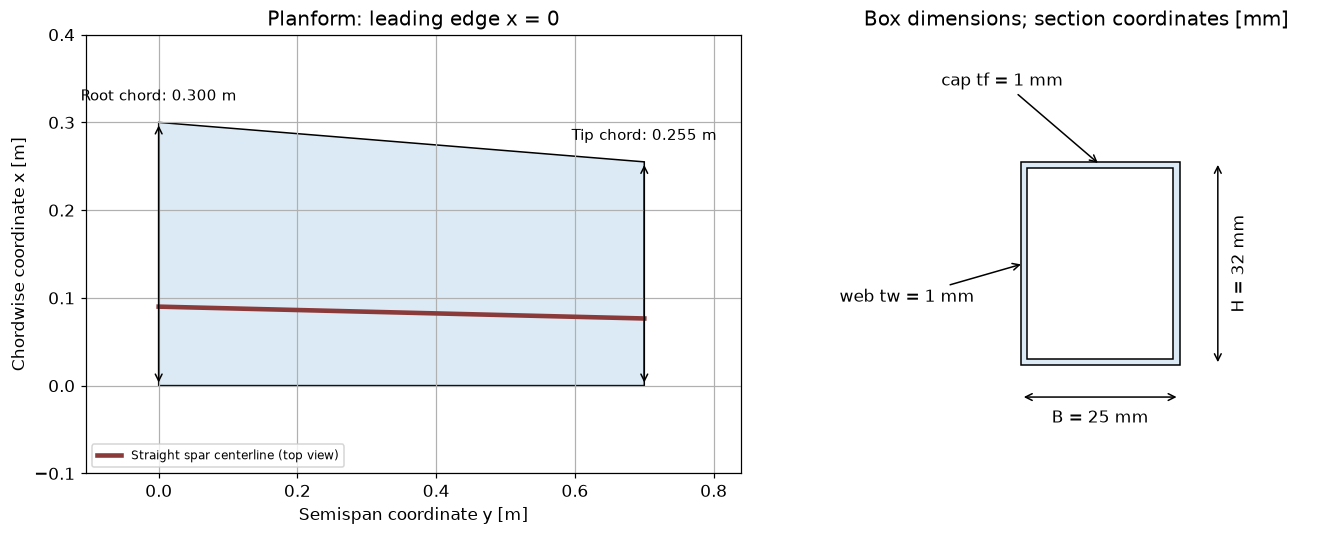

Full wing area = 0.3885 m²; AR = 5.045; G = 26.316 GPa


In [19]:
#@title 8C. Labeled planform and dimensioned section
validate(cfg)
fig,axes=plt.subplots(1,2,figsize=(13,5))
ax=axes[0]; cr=cfg['c_root']; ct=cr*cfg['taper']; ls=cfg['L']
ax.add_patch(Polygon([(0,0),(ls,0),(ls,ct),(0,cr)],fc='#dceaf5',ec='black'))
ax.plot([0,ls],[cfg['spar_xc']*cr,cfg['spar_xc']*ct],color='#8b3a3a',lw=3,label='Straight spar centerline (top view)')
for pos,ch,txt in [(0,cr,'Root chord'),(ls,ct,'Tip chord')]:
    ax.annotate('',xy=(pos,ch),xytext=(pos,0),arrowprops=dict(arrowstyle='<->'))
    ax.text(pos,ch+.025,f'{txt}: {ch:.3f} m',ha='center',fontsize=10)
ax.set(xlabel='Semispan coordinate y [m]',ylabel='Chordwise coordinate x [m]',title='Planform: leading edge x = 0')
ax.legend(loc='lower left',fontsize=8); ax.set_xlim(-.15*ls,1.2*ls); ax.set_ylim(-.10,cr+.10)
ax=axes[1]; bb=cfg['B']*1000; hh=cfg['H']*1000; tt=cfg['tf']*1000; ww=cfg['tw']*1000
ax.add_patch(Rectangle((-bb/2,-hh/2),bb,hh,fc='#dceaf5',ec='black'))
ax.add_patch(Rectangle((-bb/2+ww,-hh/2+tt),bb-2*ww,hh-2*tt,fc='white',ec='black'))
ax.annotate('',xy=(bb/2,-hh/2-5),xytext=(-bb/2,-hh/2-5),arrowprops=dict(arrowstyle='<->'))
ax.text(0,-hh/2-9,f'B = {bb:g} mm',ha='center')
ax.annotate('',xy=(bb/2+6,hh/2),xytext=(bb/2+6,-hh/2),arrowprops=dict(arrowstyle='<->'))
ax.text(bb/2+8,0,f'H = {hh:g} mm',rotation=90,va='center')
ax.annotate(f'cap tf = {tt:g} mm',xy=(0,hh/2-tt/2),xytext=(-bb,hh/2+12),arrowprops=dict(arrowstyle='->'))
ax.annotate(f'web tw = {ww:g} mm',xy=(-bb/2+ww/2,0),xytext=(-bb-16,-6),arrowprops=dict(arrowstyle='->'))
ax.set(xlim=(-bb-18,bb/2+23),ylim=(-hh/2-17,hh/2+20),title='Box dimensions; section coordinates [mm]')
ax.set_aspect('equal'); ax.axis('off'); plt.tight_layout(); plt.show()
area=cfg['L']*(cr+ct)
print(f'Full wing area = {area:.4f} m²; AR = {(2*ls)**2/area:.3f}; G = {cfg["G"]/1e9:.3f} GPa')

## 9. Load distribution and multiple flight cases

With the same semi-wing force $F$, three prescribed distributions isolate the effect of load position:

$$w_u=F/L,\qquad w_e=\frac{4F}{\pi L}\sqrt{1-(y/L)^2},\qquad w_t=\frac{2F}{L}(1-y/L).$$

All integrate to $F$. Their centroids are $L/2$, $4L/(3\pi)$ and $L/3$, respectively. Hence their root moments are $FL/2$, $4FL/(3\pi)$ and $FL/3$. The triangular distribution is a deliberately root-heavy teaching case, not an aerodynamic prediction for every tapered wing.

**Predict first:** order the root moments. Which root shear changes? Why does replacing the entire load by a tip force give $FL$, twice the uniform-load moment?

For the flight cases, we retain the elliptical shape and change $n$. Linear elasticity implies that doubling $n$ doubles signed load, moment, stress, deflection and twist. Reversing $n$ reverses curvature and swaps tension/compression faces. Design checks use absolute demands; the diagrams retain their signs.

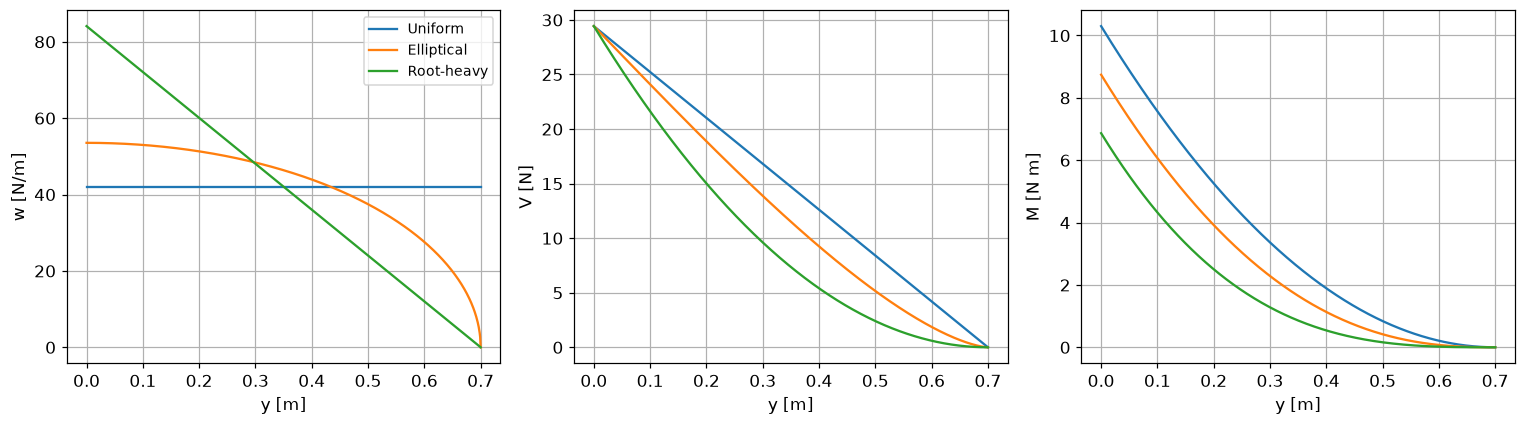

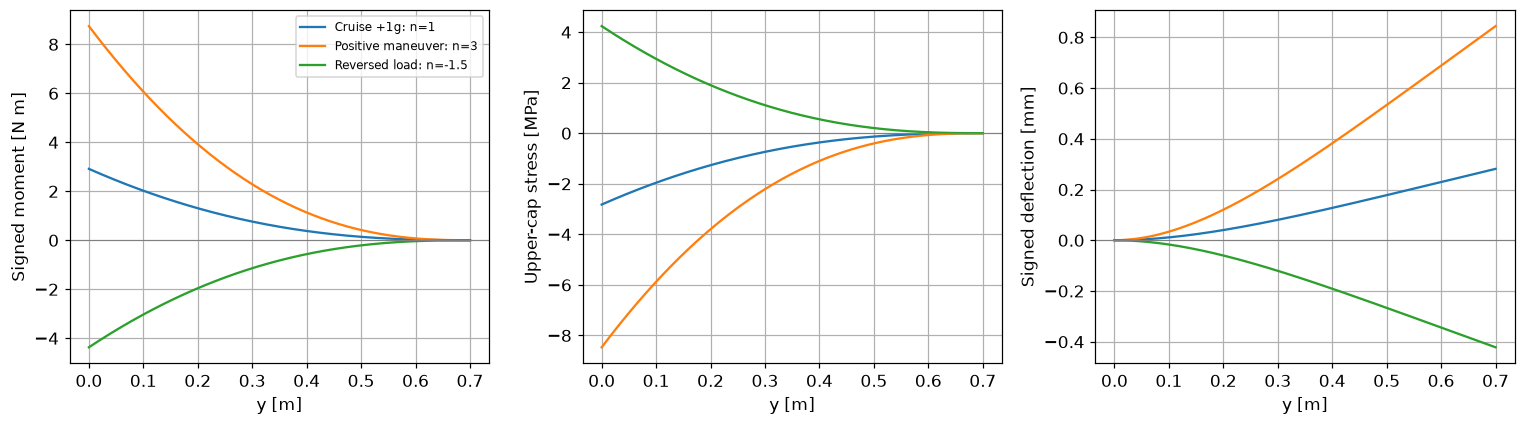

Uniform      F = 29.4300 N; centroid = 0.3500 m; Mroot = 10.3005 N m
Elliptical   F = 29.4295 N; centroid = 0.2971 m; Mroot = 8.7430 N m
Root-heavy   F = 29.4300 N; centroid = 0.2333 m; Mroot = 6.8670 N m
Positive upper-cap stress means tension; negative means compression.


In [20]:
#@title 9A. Compare shapes at the same total force
ys=np.linspace(0,cfg['L'],801); ff=cfg['n']*cfg['mass']*cfg['g']/2
fig,axes=plt.subplots(1,3,figsize=(14,4))
for sh in ['Uniform','Elliptical','Root-heavy']:
    ww=line_load(ys,cfg['L'],ff,sh); ss=section(cfg['B'],cfg['H'],cfg['tf'],cfg['tw'])
    rr=beam_integral(ys,ww,cfg['E'],ss['I'],cfg['G'],ss['J'],cfg['e'])
    for ax,key,unit in zip(axes,['w','V','M'],['N/m','N','N m']):
        ax.plot(ys,rr[key],label=sh); ax.set(xlabel='y [m]',ylabel=f'{key} [{unit}]')
    print(f'{sh:12s} F = {integral(ww,ys):.4f} N; centroid = {integral(ys*ww,ys)/integral(ww,ys):.4f} m; Mroot = {rr["M"][0]:.4f} N m')
axes[0].legend(fontsize=9); plt.tight_layout(); plt.show()
fig,axes=plt.subplots(1,3,figsize=(14,4))
for name,nval in cases.items():
    rr=assess(dict(cfg,n=nval)); bb=rr['beam']
    axes[0].plot(bb['y'],bb['M'],label=f'{name}: n={nval:g}')
    axes[1].plot(bb['y'],-bb['M']*cfg['H']/2/rr['section']['I']/1e6)
    axes[2].plot(bb['y'],bb['v']*1000)
for ax,lab in zip(axes,['Signed moment [N m]','Upper-cap stress [MPa]','Signed deflection [mm]']):
    ax.axhline(0,color='gray',lw=.7); ax.set(xlabel='y [m]',ylabel=lab)
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()
print('Positive upper-cap stress means tension; negative means compression.')

## 10. Web shear and cap buckling: why strength alone is insufficient

### Transverse shear and torsion act together

For this doubly symmetric box, the area above the neutral axis has first moment

$$Q_{NA}=\frac{BH^2-(B-2t_w)(H-2t_f)^2}{8}.$$

The two webs together provide material width $2t_w$ at that axis, giving the beam-theory estimate

$$\tau_{V,NA}=\frac{|V|Q_{NA}}{2It_w}.$$

Torsion adds $q_T=|T|/(2A_m)$, with wall stress $q_T/t$. On one web the two contributions reinforce; on the other they oppose. We use the deliberately conservative **screening envelope**

$$\tau_{screen}=\tau_{V,NA}+\max(q_T/t_w,q_T/t_f).$$

This is a simplified symmetric-box wall-stress screen, not a full closed-section shear-flow or combined-failure solution. Corners, joints, web buckling and cap transverse shear detail are excluded.

### A compressed cap can become unstable

Model the cap between webs as a long isotropic plate, width $b_p=B-2t_w$, thickness $t_f$, simply supported along its longitudinal edges, under uniform longitudinal compression:

$$\sigma_{cr}=\frac{k\pi^2E}{12(1-\nu^2)}\left(\frac{t_f}{b_p}\right)^2,\qquad k=4.$$

The buckling demand ratio is $U_b=\sigma_{compression}/(\sigma_{cr}/FS_b)$. Compare the factored material and buckling allowables; different safety factors can change which check governs. A buckling prediction above yield lies outside the elastic formula's validity. Finite rib spacing, edge fixity, imperfections and postbuckling are not resolved.

**Before running:** halving cap thickness approximately quarters its plate buckling stress. Explain why minimizing mass using only bending strength could select a poor cap.

Theory reference: [Eric R. Johnson, Aerospace Structures, Chapter 11](https://vtechworks.lib.vt.edu/bitstream/handle/10919/102306/Ch11_Buckling_Columns_Plates.pdf).

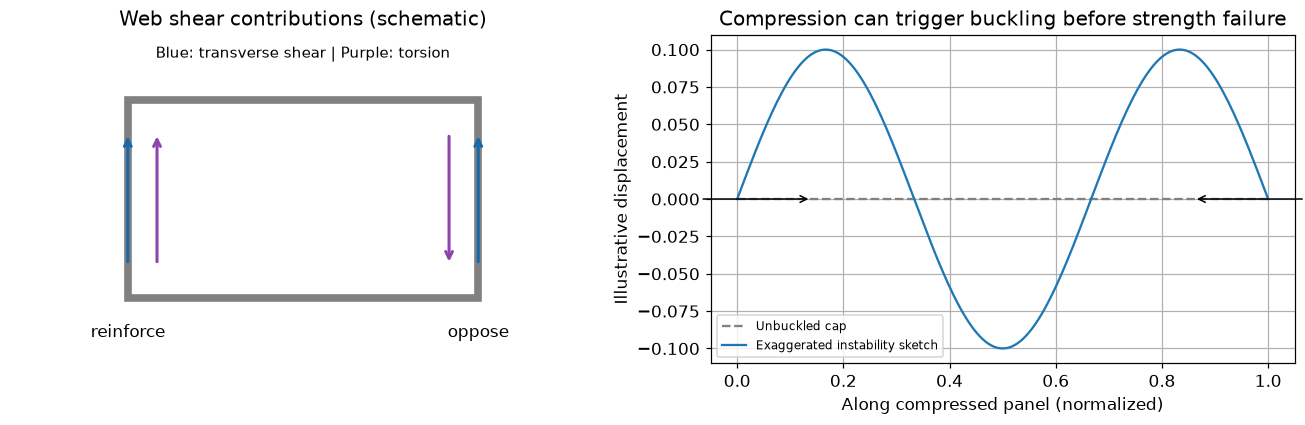

Constraint              Worst utilization    Governing load case
bending                       0.0706       Positive maneuver
web_shear                     0.0149       Positive maneuver
deflection                    0.1688       Positive maneuver
twist                         0.0236       Positive maneuver
buckling                      0.0260       Positive maneuver
Clearance = 4.482 mm; mass = 0.2079 kg
Meets all studio screens: True
Model eligibility: True (thin-wall ratio <= 0.1 and L/H >= 10 are teaching heuristics)


In [21]:
#@title 10A. Visualize shear reinforcement and a schematic cap instability
fig,axes=plt.subplots(1,2,figsize=(12,4))
ax=axes[0]; ax.add_patch(Rectangle((.2,.2),.6,.6,fill=False,lw=5,color='gray'))
for xx in [.2,.8]: ax.annotate('',xy=(xx,.70),xytext=(xx,.30),arrowprops=dict(arrowstyle='->',color='#1769aa',lw=2))
ax.annotate('',xy=(.25,.70),xytext=(.25,.30),arrowprops=dict(arrowstyle='->',color='#8e44ad',lw=2))
ax.annotate('',xy=(.75,.30),xytext=(.75,.70),arrowprops=dict(arrowstyle='->',color='#8e44ad',lw=2))
ax.text(.2,.08,'reinforce',ha='center'); ax.text(.8,.08,'oppose',ha='center')
ax.text(.5,.93,'Blue: transverse shear | Purple: torsion',ha='center',fontsize=10)
ax.set(xlim=(0,1),ylim=(0,1),title='Web shear contributions (schematic)'); ax.axis('off')
ax=axes[1]; xx=np.linspace(0,1,200)
ax.plot(xx,xx*0,'--',color='gray',label='Unbuckled cap')
ax.plot(xx,.1*np.sin(3*np.pi*xx),label='Exaggerated instability sketch')
ax.annotate('',xy=(.14,0),xytext=(-.07,0),arrowprops=dict(arrowstyle='->'))
ax.annotate('',xy=(.86,0),xytext=(1.07,0),arrowprops=dict(arrowstyle='->'))
ax.set(xlabel='Along compressed panel (normalized)',ylabel='Illustrative displacement',title='Compression can trigger buckling before strength failure')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
baseline=envelope(cfg,cases)
print('Constraint              Worst utilization    Governing load case')
for key,val in baseline['U'].items(): print(f'{key:24s}{val:12.4f}       {baseline["worst"][key]}')
print(f'Clearance = {1000*baseline["gap"]:.3f} mm; mass = {baseline["mass"]:.4f} kg')
print('Meets all studio screens:',baseline['feasible'])
print('Model eligibility:',baseline['model_ok'],'(thin-wall ratio <= 0.1 and L/H >= 10 are teaching heuristics)')

## 11. Check the complete tapered airfoil envelope

The chord varies linearly: $c(y)=c_r[1-(1-\lambda)y/L]$, where $\lambda=c_t/c_r$. The spar has constant $B,H,t_f,t_w$. Its top-view centerline follows a fixed $x/c$ fraction and its vertical center is fixed at the root fit value. We do **not** move the box vertically independently at every station to make it fit.

At each of 21 stations, sample 121 points across the box width and calculate both upper and lower vertical gaps. Reject a box extending outside the chord before interpolation. The smallest gap over the entire sampled span must exceed the specified clearance. This is a sampled geometric check, not a complete CAD intersection proof; root-only clearance can miss a tip collision.

**Predict:** will tapering the airfoil around an unchanged spar improve or worsen tip clearance?

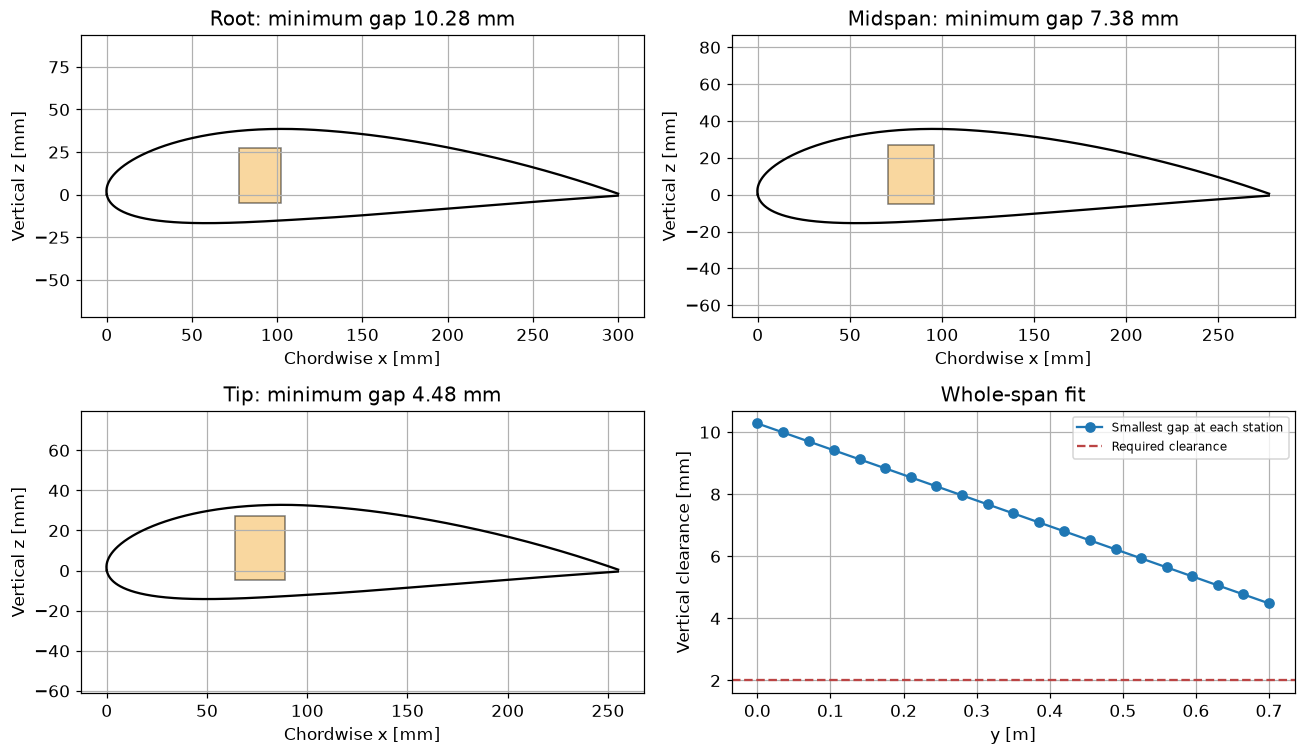

In [22]:
#@title 11A. Root, midspan, tip and minimum clearance along the span
pack=packaging(cfg); xu0,zu0,xl0,zl0=airfoil(cfg['naca'])
fig,axes=plt.subplots(2,2,figsize=(12,7))
for ax,idx,lab in zip(axes.flat[:3],[0,10,20],['Root','Midspan','Tip']):
    cc=pack['chord'][idx]; centerx=cfg['spar_xc']*cc
    ax.plot(xu0*cc*1000,zu0*cc*1000,'k'); ax.plot(xl0*cc*1000,zl0*cc*1000,'k')
    ax.add_patch(Rectangle(((centerx-cfg['B']/2)*1000,(pack['center']-cfg['H']/2)*1000),cfg['B']*1000,cfg['H']*1000,fc='#f5b041',alpha=.5,ec='black'))
    ax.set(xlabel='Chordwise x [mm]',ylabel='Vertical z [mm]',title=f'{lab}: minimum gap {pack["gap"][idx]*1000:.2f} mm'); ax.set_aspect('equal',adjustable='datalim')
axes[1,1].plot(pack['y'],pack['gap']*1000,'o-',label='Smallest gap at each station')
axes[1,1].axhline(cfg['clearance']*1000,ls='--',color='#b44',label='Required clearance')
axes[1,1].set(xlabel='y [m]',ylabel='Vertical clearance [mm]',title='Whole-span fit'); axes[1,1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Independent numerical verification: a beam finite-element model

We now solve the same idealized half-wing using a different numerical method. Agreement checks the implementation of the beam model; it does **not** validate its assumptions against a real wing. Both models still assume a straight, slender, linearly elastic beam, small displacement, constant $EI$, and negligible shear deformation.

### 1. What does an element represent?

Split the semispan into $n_e$ short elements of length $\ell$. Each node has two unknowns: vertical displacement $v$ and section rotation $\theta=dv/dy$. Positive displacement and applied load point upward. At the clamped root, $v(0)=\theta(0)=0$; the tip has no applied point force or couple.

For one element, collect the four unknowns in

$$\mathbf d_e=[v_1,\theta_1,v_2,\theta_2]^T.$$

Using $\xi=(y-y_1)/\ell$, approximate the displacement between nodes with cubic Hermite functions:

$$v(\xi)=\mathbf N(\xi)\mathbf d_e,$$

$$\mathbf N=[1-3\xi^2+2\xi^3,\;\ell(\xi-2\xi^2+\xi^3),\;3\xi^2-2\xi^3,\;\ell(-\xi^2+\xi^3)].$$

These functions reproduce the displacement **and slope** at both element ends. Curvature is $d^2v/dy^2$; bending strain energy is

$$U_e=\frac12\int_0^\ell EI\left(\frac{d^2v}{dy^2}\right)^2dy
=\frac12\mathbf d_e^T\mathbf k_e\mathbf d_e.$$

Substituting the shape functions and integrating gives

$$\mathbf k_e=\frac{EI}{\ell^3}
\begin{bmatrix}
12&6\ell&-12&6\ell\\
6\ell&4\ell^2&-6\ell&2\ell^2\\
-12&-6\ell&12&-6\ell\\
6\ell&2\ell^2&-6\ell&4\ell^2
\end{bmatrix}.$$

The distributed force must also be converted consistently into nodal forces **and nodal moments**:

$$\mathbf f_e=\int_0^\ell\mathbf N^T w(y_1+s)\,ds.$$

For a uniform load this reduces to

$$\mathbf f_e=[w\ell/2,\;w\ell^2/12,\;w\ell/2,\;-w\ell^2/12]^T.$$

The code evaluates this integral using Gauss quadrature, assembles neighboring contributions into $\mathbf K\mathbf d=\mathbf f$, removes the two fixed root degrees of freedom, and solves the remaining linear system. The root reaction force and moment follow from the constrained entries of $\mathbf r=\mathbf K\mathbf d-\mathbf f$.

**Before running:** sketch the root reactions. For an upward distributed load, what signs must the root reaction force and root reaction moment have in this convention?


In [23]:
import numpy as np
import matplotlib.pyplot as plt

def beam_fem(L, EI, wfun, ne=20):
    """Constant-EI Euler--Bernoulli cantilever; SI units; upward load positive.

    Return nodes, displacements, slopes, and [root force, root moment].
    The moment reaction uses the rotation DOF convention theta=dv/dy.
    """
    if L <= 0 or EI <= 0 or int(ne) != ne or ne < 1:
        raise ValueError('Require L>0, EI>0 and a positive integer element count.')
    ne = int(ne)
    nodes = np.linspace(0., L, ne + 1)
    le = L / ne
    ke = EI / le**3 * np.array([
        [12, 6*le, -12, 6*le],
        [6*le, 4*le**2, -6*le, 2*le**2],
        [-12, -6*le, 12, -6*le],
        [6*le, 2*le**2, -6*le, 4*le**2]])
    K = np.zeros((2*(ne+1), 2*(ne+1)))
    f = np.zeros(2*(ne+1))
    gx, gw = np.polynomial.legendre.leggauss(8)
    xi = (gx + 1.) / 2.
    N = np.column_stack((1-3*xi**2+2*xi**3,
        le*(xi-2*xi**2+xi**3), 3*xi**2-2*xi**3,
        le*(-xi**2+xi**3)))
    for element in range(ne):
        dofs = np.arange(2*element, 2*element+4)
        local_y = nodes[element] + le*xi
        loads = np.broadcast_to(np.asarray(wfun(local_y), dtype=float), xi.shape)
        fe = N.T @ (gw * le/2. * loads)
        K[np.ix_(dofs, dofs)] += ke
        f[dofs] += fe
    d = np.zeros_like(f)
    d[2:] = np.linalg.solve(K[2:, 2:], f[2:])
    reactions = (K @ d - f)[:2]
    return nodes, d[0::2], d[1::2], reactions

print('Beam FEM ready. Units: m, N, Pa, N m²; rotation is in radians.')


Beam FEM ready. Units: m, N, Pa, N m²; rotation is in radians.


### 2. Check a case with a known exact answer

For a uniform load $w_0$ on a constant-stiffness cantilever, the exact displacement is

$$v(y)=\frac{w_0 y^2}{24EI}(6L^2-4Ly+y^2),\qquad
v(L)=\frac{w_0L^4}{8EI}.$$

The exact root reactions are $R_v=-w_0L$ and $R_\theta=-w_0L^2/2$. First compare these values with the finite-element result. Cubic beam elements with consistent loading reproduce the nodal displacements of this constant-$EI$ uniform-load case to numerical precision; therefore a tiny tip error here is expected, even on a coarse mesh. The displacement **between** nodes is still an approximation.

**Hand calculation:** use your section $I$, material $E$, semispan $L$, and half-wing force $F=nmg/2$ to compute $w_0=F/L$ and $v(L)$. Record your result before running the check.


In [24]:
fem_section = section(cfg['B'], cfg['H'], cfg['tf'], cfg['tw'])
fem_EI = cfg['E'] * fem_section['I']
fem_L = cfg['L']
fem_F = cfg['n'] * cfg['mass'] * cfg['g'] / 2.
fem_w0 = fem_F / fem_L
fem_nodes, fem_v, fem_slope, fem_r = beam_fem(
    fem_L, fem_EI, lambda yy: np.full_like(yy, fem_w0), ne=10)
fem_exact_tip = fem_w0 * fem_L**4 / (8*fem_EI)
fem_exact_r = np.array([-fem_F, -fem_F*fem_L/2.])
print('UNIFORM-LOAD BENCHMARK')
print(f'Analytical tip displacement: {1000*fem_exact_tip:.6f} mm')
print(f'FEM tip displacement:        {1000*fem_v[-1]:.6f} mm')
print(f'Tip absolute difference:    {1000*abs(fem_v[-1]-fem_exact_tip):.3e} mm')
print(f'Root force: FEM {fem_r[0]:.6f} N; exact {fem_exact_r[0]:.6f} N')
print(f'Root moment: FEM {fem_r[1]:.6f} N m; exact {fem_exact_r[1]:.6f} N m')
assert np.allclose(fem_v[-1], fem_exact_tip, rtol=1e-7, atol=1e-12)
assert np.allclose(fem_r, fem_exact_r, rtol=1e-7, atol=1e-10)


UNIFORM-LOAD BENCHMARK
Analytical tip displacement: 1.091375 mm
FEM tip displacement:        1.091375 mm
Tip absolute difference:    3.979e-13 mm
Root force: FEM -29.430000 N; exact -29.430000 N
Root moment: FEM -10.300500 N m; exact -10.300500 N m


### 3. Elliptical loading: refine the mesh and check equilibrium

Use the same total half-wing force with

$$w(y)=\frac{4F}{\pi L}\sqrt{1-(y/L)^2}.$$

Its load centroid is $\bar y=4L/(3\pi)$, so the expected root reactions are $-F$ and $-4FL/(3\pi)$. An independent reference for tip displacement follows by adding the effect of each small point load $dF=w(s)ds$ at position $s$:

$$v(L)=\int_0^L\frac{w(s)s^2(3L-s)}{6EI}\,ds.$$

The kernel is the tip displacement per unit force applied at $s$. We evaluate this reference with high-order quadrature and compare meshes with 5, 10, 20, and 40 elements. Here the load has a square-root tip behavior; the remaining tip-displacement error is largely quadrature error. This experiment checks load integration, assembly, boundary conditions and global equilibrium; it is not evidence that a real wing follows beam theory.

**Inspect:** do the errors decrease? Are the root reactions consistent with the applied total force and its moment? An almost unchanged answer across meshes is useful only after these independent checks pass.


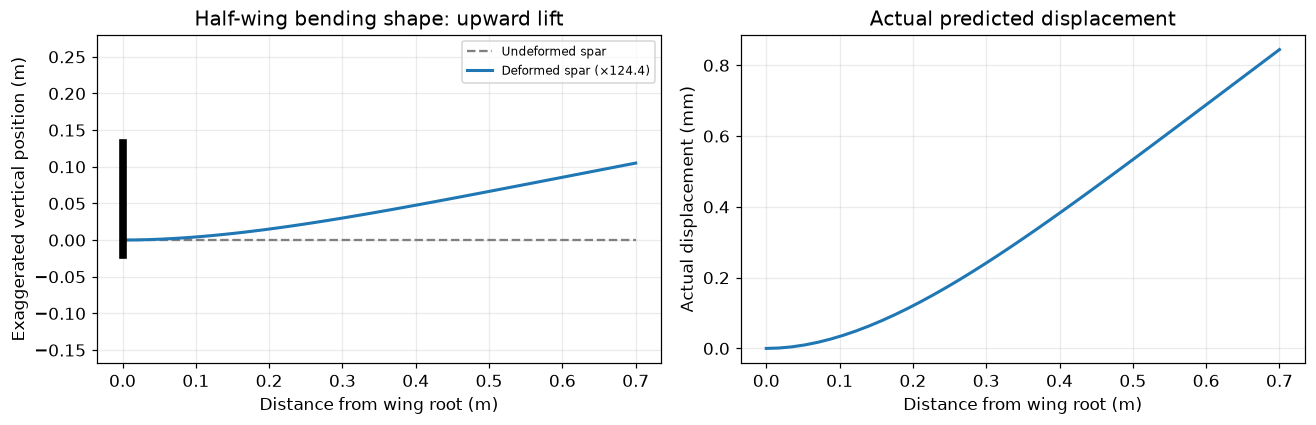

Independent integral reference: 0.844338 mm
Elements | tip (mm) | tip error (%) | force error (%) | moment error (%)
       5 |  0.84442 |      0.009414 |        0.002722 |         0.006428
      10 |  0.84437 |      0.003322 |        0.000962 |         0.002269
      20 |  0.84435 |      0.001173 |        0.000340 |         0.000802
      40 |  0.84434 |      0.000415 |        0.000120 |         0.000283


In [25]:
fem_elliptical = lambda yy: 4*fem_F/(np.pi*fem_L) * np.sqrt(
    np.maximum(0., 1-(np.asarray(yy)/fem_L)**2))
# s=L sin(t) removes the square-root endpoint behavior in the reference integral.
fem_gx, fem_gw = np.polynomial.legendre.leggauss(100)
fem_t = (fem_gx+1)*np.pi/4
fem_s = fem_L*np.sin(fem_t)
fem_reference = np.sum(fem_gw*np.pi/4 * fem_elliptical(fem_s)
    * fem_s**2*(3*fem_L-fem_s)/(6*fem_EI) * fem_L*np.cos(fem_t))
fem_ref_r = np.array([-fem_F, -4*fem_F*fem_L/(3*np.pi)])
print(f'Independent integral reference: {1000*fem_reference:.6f} mm')
print('Elements | tip (mm) | tip error (%) | force error (%) | moment error (%)')
for fem_ne in (5, 10, 20, 40):
    fem_y2, fem_v2, fem_theta2, fem_r2 = beam_fem(fem_L, fem_EI, fem_elliptical, fem_ne)
    fem_err = 100*abs(fem_v2[-1]-fem_reference)/max(abs(fem_reference), 1e-14)
    fem_re = 100*np.abs(fem_r2-fem_ref_r)/np.maximum(np.abs(fem_ref_r), 1e-14)
    print(f'{fem_ne:8d} | {1000*fem_v2[-1]:8.5f} | {fem_err:13.6f} | {fem_re[0]:15.6f} | {fem_re[1]:16.6f}')

fem_scale = 0.15*fem_L/max(np.max(np.abs(fem_v2)), 1e-12)
fem_fig, fem_ax = plt.subplots(1, 2, figsize=(12, 4))
fem_ax[0].plot(fem_y2, np.zeros_like(fem_y2), '--', color='0.5', label='Undeformed spar')
fem_ax[0].plot(fem_y2, fem_scale*fem_v2, lw=2, label=f'Deformed spar (×{fem_scale:.1f})')
fem_ax[0].plot([0, 0], [-0.03*fem_L, 0.19*fem_L], color='black', lw=5)
fem_ax[0].set(xlabel='Distance from wing root (m)', ylabel='Exaggerated vertical position (m)',
    title='Half-wing bending shape: upward lift')
fem_ax[0].axis('equal')
fem_ax[0].legend(fontsize=8)
fem_ax[1].plot(fem_y2, 1000*fem_v2, lw=2)
fem_ax[1].set(xlabel='Distance from wing root (m)', ylabel='Actual displacement (mm)',
    title='Actual predicted displacement')
for fem_axis in fem_ax:
    fem_axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [26]:
#@title FEM bridge — compare directly against our original integration algorithm
bridge=assess(cfg,stations=4001)['beam']
bridge_error=100*abs(bridge['v'][-1]-fem_v2[-1])/max(abs(fem_v2[-1]),1e-14)
print(f'Direct curvature integration: {bridge["v"][-1]*1000:.6f} mm')
print(f'Independent FEM (40 elements): {fem_v2[-1]*1000:.6f} mm')
print(f'Difference: {bridge_error:.5f}% (teaching tolerance: 0.1%)')
assert bridge_error < .1, 'Investigate load consistency, boundary conditions, units or mesh.'
assert fem_err < .1 and np.max(fem_re)<.1, 'FEM equilibrium/reference check failed.'
print('Numerical verification passed. Physical validation remains untested.')

Direct curvature integration: 0.844334 mm
Independent FEM (40 elements): 0.844342 mm
Difference: 0.00093% (teaching tolerance: 0.1%)
Numerical verification passed. Physical validation remains untested.


## 13. Search the design space and explain the trade-off

Hold width, planform, material and load cases fixed. Vary box height and use equal cap/web thickness for this search. Every candidate is checked against **all three load cases**, bending, shear, deflection, twist, cap buckling and sampled whole-span clearance. Thin-wall and slender-beam heuristics must also hold.

Define $U_{max}=\max(U_\sigma,U_\tau,U_v,U_\phi,U_b)$. A candidate with $U_{max}\le1$ is still rejected if it fails fit or model eligibility. The Pareto points shown below are nondominated in **mass and $U_{max}$**: no other accepted candidate is both lighter and lower in demand ratio. They are Pareto points only within this finite grid and these selected objectives.

**Before running:** predict where the feasible region will lie. Very thin caps may buckle; tall boxes may not fit; short boxes may deflect too much. A minimum located at the grid edge calls for a wider search, not a claim of global optimality.

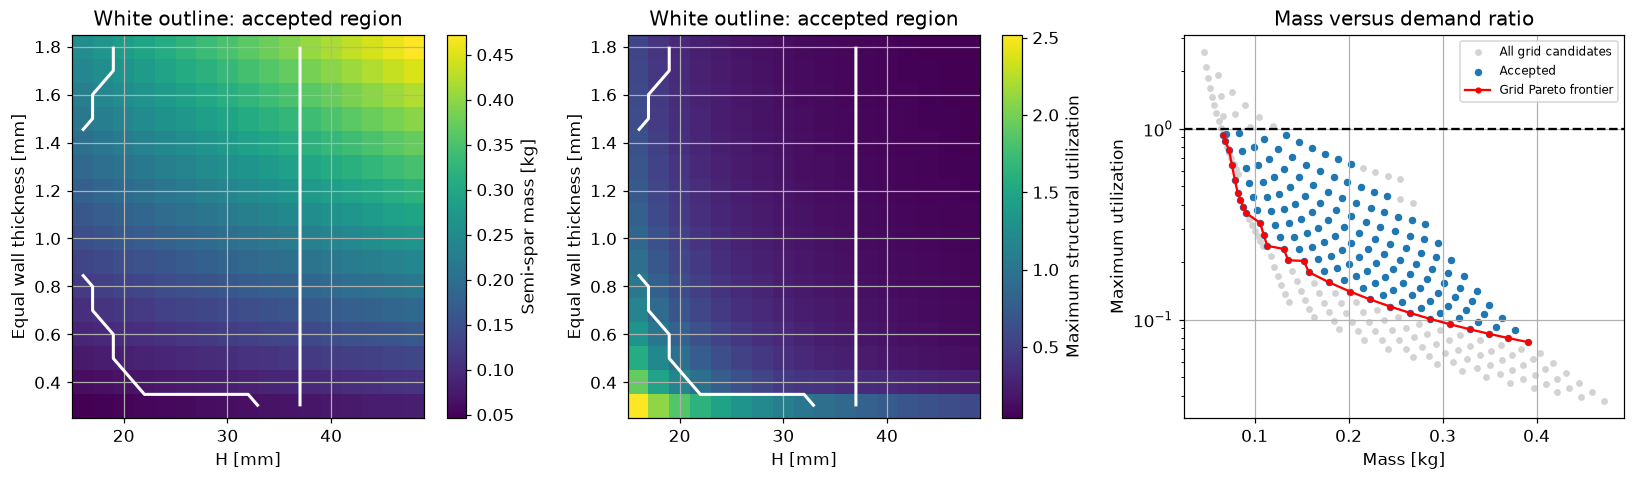

Lightest accepted grid point: {'H_m': 0.034, 't_m': 0.0003, 'mass_kg': 0.06622560000000013, 'Umax': np.float64(0.9321099225348023), 'feasible': True, 'gap_m': 0.0034824560142439134, 'governing': 'buckling'}
Candidate touches a grid boundary: expand the grid before claiming a better optimum.


In [27]:
#@title 13A. Feasibility maps, Pareto plot and lightest grid candidate
heights=np.linspace(16,48,17)*1e-3
thicknesses=np.linspace(.30,1.80,16)*1e-3
grid_rows=[]; grid_mass=np.zeros((len(thicknesses),len(heights))); grid_u=grid_mass.copy(); grid_ok=np.zeros_like(grid_mass,dtype=bool)
for it,tt in enumerate(thicknesses):
    for ih,hh in enumerate(heights):
        candidate=dict(cfg,H=float(hh),tf=float(tt),tw=float(tt))
        result=envelope(candidate,cases)
        grid_mass[it,ih]=result['mass']; grid_u[it,ih]=max(result['U'].values()); grid_ok[it,ih]=result['feasible']
        grid_rows.append(dict(H_m=float(hh),t_m=float(tt),mass_kg=result['mass'],Umax=max(result['U'].values()),
            feasible=result['feasible'],gap_m=result['gap'],governing=result['governing']))
fig,axes=plt.subplots(1,3,figsize=(15,4.5))
for ax,values,label in zip(axes[:2],[grid_mass,grid_u],['Semi-spar mass [kg]','Maximum structural utilization']):
    im=ax.pcolormesh(heights*1000,thicknesses*1000,values,shading='nearest',cmap='viridis'); fig.colorbar(im,ax=ax,label=label)
    if grid_ok.any() and not grid_ok.all(): ax.contour(heights*1000,thicknesses*1000,grid_ok.astype(float),levels=[.5],colors='white',linewidths=2)
    ax.set(xlabel='H [mm]',ylabel='Equal wall thickness [mm]',title='White outline: accepted region')
feasible_rows=sorted([r for r in grid_rows if r['feasible']],key=lambda r:r['mass_kg'])
axes[2].scatter([r['mass_kg'] for r in grid_rows],[r['Umax'] for r in grid_rows],s=12,color='lightgray',label='All grid candidates')
pareto=[]; best_u=float('inf')
for row in feasible_rows:
    if row['Umax'] < best_u: pareto.append(row); best_u=row['Umax']
if feasible_rows:
    axes[2].scatter([r['mass_kg'] for r in feasible_rows],[r['Umax'] for r in feasible_rows],s=15,label='Accepted')
    axes[2].plot([r['mass_kg'] for r in pareto],[r['Umax'] for r in pareto],'r.-',label='Grid Pareto frontier')
    chosen=feasible_rows[0]; selected=dict(cfg,H=chosen['H_m'],tf=chosen['t_m'],tw=chosen['t_m'])
    print('Lightest accepted grid point:',chosen)
    if chosen['H_m'] in [heights[0],heights[-1]] or chosen['t_m'] in [thicknesses[0],thicknesses[-1]]:
        print('Candidate touches a grid boundary: expand the grid before claiming a better optimum.')
else:
    selected=dict(cfg); print('No accepted grid candidate. Baseline retained for diagnosis; it is not labeled optimal.')
axes[2].axhline(1,ls='--',color='black'); axes[2].set(xlabel='Mass [kg]',ylabel='Maximum utilization',title='Mass versus demand ratio'); axes[2].set_yscale('log'); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 14. Sensitivity and numerical uncertainty experiment

First change one input at a time by ±10% and compare the selected constraint ratios. Then sample 200 hypothetical manufacturing/loading scenarios with a fixed random seed: load multiplier uniform in $[0.9,1.1]$, modulus multiplier uniform in $[0.85,1.15]$, and a common wall-thickness offset uniform in ±0.1 mm. Derive $G$ from each sampled $E$ and the same $\nu$.

The pass fraction is **conditional on these invented distributions**, not a measured failure probability or reliability certification. Nominally passing and insensitive to assumed scatter are different claims. We keep material strengths fixed in this illustrative experiment; real property correlations require data.

**Predict:** which check changes most when $E$ decreases? Why does uncertainty in thickness affect both stiffness and buckling?

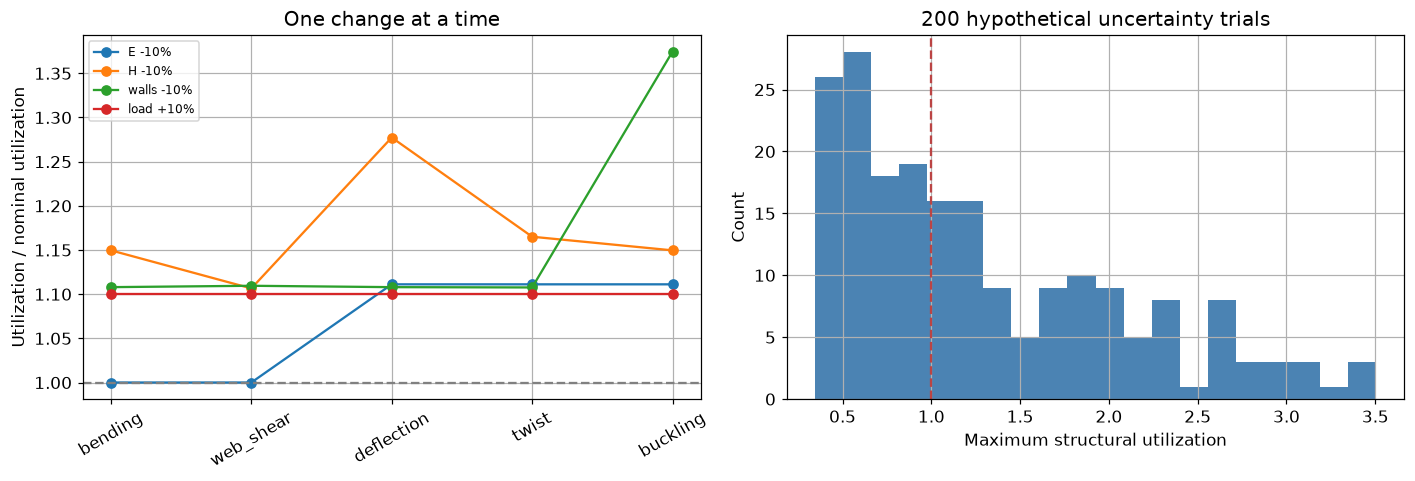

Conditional pass fraction: 47.5%
If this is unsatisfactory, increase margins and rerun; the minimum-mass point is not automatically robust.


In [28]:
#@title 14A. One-at-a-time sensitivity and seeded numerical trials
nominal=envelope(selected,cases); labels=list(nominal['U']); nominal_u=np.array(list(nominal['U'].values()))
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for name,factor,key in [('E -10%',.9,'E'),('H -10%',.9,'H'),('walls -10%',.9,'walls'),('load +10%',1.1,'load')]:
    cc=dict(selected); case_tmp=cases.copy()
    if key=='walls': cc['tf']*=factor; cc['tw']*=factor
    elif key=='load': case_tmp={k:n*factor for k,n in cases.items()}
    else: cc[key]*=factor
    cc['G']=cc['E']/(2*(1+cc['nu']))
    uu=envelope(cc,case_tmp)['U']
    axes[0].plot(labels,[uu[k]/max(nominal['U'][k],1e-12) for k in labels],'o-',label=name)
axes[0].axhline(1,color='gray',ls='--'); axes[0].set(ylabel='Utilization / nominal utilization',title='One change at a time'); axes[0].tick_params(axis='x',rotation=30); axes[0].legend(fontsize=8)
rng=np.random.default_rng(446); trials=[]
for trial in range(200):
    cc=dict(selected); load_multiplier=float(rng.uniform(.9,1.1)); modulus_multiplier=float(rng.uniform(.85,1.15)); offset=float(rng.uniform(-.0001,.0001))
    cc['E']*=modulus_multiplier; cc['G']=cc['E']/(2*(1+cc['nu'])); cc['tf']+=offset; cc['tw']+=offset
    rr=envelope(cc,{k:n*load_multiplier for k,n in cases.items()})
    trials.append(dict(trial=trial,load_multiplier=load_multiplier,E_multiplier=modulus_multiplier,wall_offset_m=offset,Umax=max(rr['U'].values()),passed=rr['feasible']))
axes[1].hist([r['Umax'] for r in trials],bins=20,color='#4b83b3'); axes[1].axvline(1,color='#b44',ls='--')
axes[1].set(xlabel='Maximum structural utilization',ylabel='Count',title='200 hypothetical uncertainty trials')
plt.tight_layout(); plt.show()
pass_fraction=np.mean([r['passed'] for r in trials]); print(f'Conditional pass fraction: {pass_fraction:.1%}')
print('If this is unsatisfactory, increase margins and rerun; the minimum-mass point is not automatically robust.')

## 15. Engineering record and CAD-ready numerical export

Keep a baseline plus three deliberate revisions, with your reason for each change. A memo must explain: **prediction → computed evidence → independent check → decision → remaining limitation**. Record AI assistance and one error or assumption you checked yourself. Each of the three team members must be able to explain a different stage.

The export cell creates a local ZIP with input JSON, results and design-space CSV, uncertainty trials, spanwise results, root airfoil coordinates and box stations for CAD. Coordinates are in metres. The exported airfoil is a section and the box coordinates describe the straight spar; they are not an STL or a meshed solid. Download from the Colab Files pane or the link shown below.

Changing a saved copy in Google Drive does not update it from GitHub: reopen the course link to obtain a new release.

In [29]:
#@title 15A. Design history — replace the supplied examples with your own decisions
revision_specs=[('Baseline',dict(cfg),'Initial dimensions'),
    ('Revision 1',dict(cfg,tf=cfg['tf']*.9,tw=cfg['tw']*.9),'Reduce wall thickness by 10%; inspect buckling'),
    ('Revision 2',dict(cfg,H=cfg['H']*.95),'Reduce height by 5%; compare fit and stiffness'),
    ('Revision 3',dict(selected),'Lightest accepted grid candidate, or baseline if none exists')]
history=[]
for name,cc,reason in revision_specs:
    rr=envelope(cc,cases)
    history.append(dict(revision=name,reason=reason,H_mm=cc['H']*1000,tf_mm=cc['tf']*1000,tw_mm=cc['tw']*1000,mass_kg=rr['mass'],Umax=max(rr['U'].values()),gap_mm=rr['gap']*1000,passed=rr['feasible']))
    print(f'{name:12s} mass={rr["mass"]:.4f} kg | Umax={max(rr["U"].values()):.3f} | pass={rr["feasible"]} | {reason}')
print('These are illustrative revisions, not evidence of your own design reasoning. Edit the reasons and candidates.')

Baseline     mass=0.2079 kg | Umax=0.169 | pass=True | Initial dimensions
Revision 1   mass=0.1878 kg | Umax=0.186 | pass=True | Reduce wall thickness by 10%; inspect buckling
Revision 2   mass=0.2019 kg | Umax=0.191 | pass=True | Reduce height by 5%; compare fit and stiffness
Revision 3   mass=0.0662 kg | Umax=0.932 | pass=True | Lightest accepted grid candidate, or baseline if none exists
These are illustrative revisions, not evidence of your own design reasoning. Edit the reasons and candidates.


In [30]:
#@title 15B. Export reproducible report, results and coordinates
from pathlib import Path
import csv,json,zipfile
outdir=Path('MIE446_numerical_submission'); outdir.mkdir(exist_ok=True)
def csv_export(name,rows):
    if rows:
        with (outdir/name).open('w',newline='',encoding='utf-8') as f:
            writer=csv.DictWriter(f,fieldnames=list(rows[0])); writer.writeheader(); writer.writerows(rows)
def json_default(value):
    if isinstance(value,np.generic): return value.item()
    if isinstance(value,np.ndarray): return value.tolist()
    raise TypeError(type(value).__name__)
(outdir/'inputs.json').write_text(json.dumps(dict(configuration=selected,load_cases=cases),indent=2,default=json_default))
final=envelope(selected,cases); csv_export('design_history.csv',history); csv_export('design_space.csv',grid_rows); csv_export('uncertainty_trials.csv',trials)
csv_export('checks.csv',[dict(check=k,utilization=v,governing_case=final['worst'][k]) for k,v in final['U'].items()])
span_rows=[]
for label,rr in final['results'].items():
    bb=rr['beam']
    for j,yy in enumerate(bb['y']): span_rows.append(dict(case=label,y_m=yy,load_N_per_m=bb['w'][j],shear_N=bb['V'][j],moment_Nm=bb['M'][j],torque_Nm=bb['T'][j],deflection_m=bb['v'][j],twist_rad=bb['phi'][j]))
csv_export('span_results.csv',span_rows)
au,az,al,alz=airfoil(selected['naca']); cr=selected['c_root']
csv_export('airfoil_coordinates.csv',[dict(surface=lab,x_m=float(xx*cr),y_m=0.,z_m=float(zz*cr)) for lab,xxs,zzs in [('upper',au,az),('lower',al,alz)] for xx,zz in zip(xxs,zzs)])
pp=packaging(selected); boxrows=[]
for yy,ch in zip(pp['y'],pp['chord']):
    for corner,dx,dz in [('UL',-1,1),('UR',1,1),('LR',1,-1),('LL',-1,-1)]:
        boxrows.append(dict(station_y_m=float(yy),corner=corner,x_m=float(selected['spar_xc']*ch+dx*selected['B']/2),z_m=float(pp['center']+dz*selected['H']/2)))
csv_export('spar_box_stations.csv',boxrows)
memo=f"""# MIE 446 numerical design record

Selected semi-spar mass: {final['mass']:.5f} kg
Maximum structural utilization: {max(final['U'].values()):.4f}
Minimum sampled spanwise clearance: {final['gap']*1000:.3f} mm
Meets selected screens: {final['feasible']}
Hypothetical uncertainty pass fraction: {pass_fraction:.1%}
Baseline integral/FEM tip difference: {bridge_error:.5f}%

Student claim and rationale: [complete]
Independent hand calculation: [complete]
Three revisions and reasons: [complete]
AI assistance and verification: [complete]
Remaining limitations: prescribed aerodynamic load, constant-section EB beam,
approximate symmetric-box shear, ideal long-plate cap buckling, sampled geometry.
No experimental validation; web buckling, joints, fatigue and combined failure excluded.
"""
(outdir/'design_memo.md').write_text(memo,encoding='utf-8')
zip_path=Path('MIE446_numerical_submission.zip')
with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as z:
    for path in sorted(outdir.iterdir()): z.write(path,path.name)
print('Created',zip_path.name)
try:
    from IPython.display import FileLink, display
    display(FileLink(str(zip_path)))
except ImportError:
    print('Download the ZIP through the notebook Files pane.')

Created MIE446_numerical_submission.zip
Download the ZIP through the notebook Files pane.


## Sources and final interpretation

- [Supplied wing-design teaching video](https://www.youtube.com/watch?v=KbvpDjdusuE): inspiration for the visible inputs, sizing, fit checks and iterative workflow. The added FEM, uncertainty and buckling activities are independent extensions, not claims about other unseen videos.
- [TU Delft: Euler–Bernoulli beam elements](https://teachbooks.tudelft.nl/computational-modelling/structural_linear/euler_bernouilli.html): beam finite-element formulation.
- [Eric R. Johnson: Aerospace Structures, Chapter 11](https://vtechworks.lib.vt.edu/bitstream/handle/10919/102306/Ch11_Buckling_Columns_Plates.pdf): classical plate buckling background.

Keep four claims separate: **the equations were implemented correctly**, **the numerical answer converged**, **the candidate passed the selected design checks**, and **the physical model represents an actual wing**. This notebook can provide evidence for the first three. The fourth needs suitable experimental or other independently validated evidence.